In [1]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import Self
from dataclasses import dataclass
from typing import Dict, List, Tuple, Iterable

import math

%load_ext autoreload
%autoreload 2

In [2]:
# Wealth Levels:
wealth_req = [0] * 51
consume_req = [0] * 51
luxuries_req = [0] * 51
for level in range(51): # 0 to 50 inclusive
    wealth_req[level] = 2 ** (level * 0.3) - 1     # 2^0.3x - 1
    consume_req[level] = level * 0.1 + 0.02 * max(0, level - 4) * 2 ** (level * 0.3) # 0.02 * max(0, x - 4) * 2^0.3x + 0.1x
    luxuries_req[level] = 2 ** (0.25 * max(0, level - 4)) - max(1, math.log(level - 4)) if level > 4 else 0 # 2^0.25(x-4) - max(ln(x-4), 1)

# Gets a wealth level based off per capita wealth.
# Returns an integer from 0 to 50 inclusive.
def get_wealth_level(pop: float, wealth: float) -> int:
    if wealth == 0:
        return 0
    
    per_capita = wealth / pop
    for level in range(50):
        if per_capita < wealth_req[level+1]:
            return level
        
    return 50

# Gets a shortage modifier based off wealth level.
# Higher wealth levels decreases shortage impact on the pop. It also applies a buffer.
# Eg. At wealth level 50, shortages only apply at a 50% shortage or higher. The effects of the shortage are also 50% less.
def get_shortage_modifier(wealth_level: int, shortage: float) -> float:
    buffer = wealth_level / 100.0
    effective_shortage = shortage - buffer

    if effective_shortage <= 0:
        return 0.0

    modifier = effective_shortage * (1.0 - (wealth_level / 100.0))
    return modifier

def get_land_productivity(land: float, workers: float, base_productivity: float = 2.0, saturation: float = 1.0, exp: float = 1.0) -> float:
    if land <= 0.0 or workers <= 0.0:
        return 0.0

    land_per_worker = land / workers
    productivity = base_productivity * ((land_per_worker / (land_per_worker + saturation)) ** exp)

    return productivity

def get_wage_share(share_min: float = 0.05, share_max: float = 0.85, ) -> float:
    return share_min

# This returns how many commoners will work elite owned land at a given wage share. 
# This is important for determining how many workers are producing for the elite vs how many are producing for themselves.
def get_workers_at_wage_share(wage_share: float, land_elite: float, land_commoner: float, commoners: float, slaves: float, desperation: float = 0.1, saturation: float = 1.0, exp: float = 1.0) -> float:
    # numerator = (W**1/e) * L_e * (L_c + sat * C) - L_c * L_e - L_c * sat * S
    # denominator = sat * (L_c + (W**1/e) * L_e)
    # C_e = numerator / denominator
    if commoners <= 0.0 or land_elite <= 0.0:
        return 0.0
    
    # 90% cap
    wage_eff = min(wage_share, 0.9)
    w_root = wage_eff ** (1/exp)

    # Productivity driven model
    numerator = w_root * land_elite * (land_commoner + saturation * commoners) - land_commoner * ( land_elite + saturation * slaves )
    denominator = saturation * (land_commoner + w_root * land_elite)
    ce_econ = numerator / denominator if abs(denominator) > 1e-8 else 0.0
    ce_econ = max(0.0, min(ce_econ, commoners))
    
    # Desperation driven model
    if land_commoner <= 0.0:
        return ce_econ
    r = land_elite / land_commoner
    ce_final = ce_econ + desperation * r * wage_eff * (commoners - ce_econ)
    ce_final = max(0.0, min(ce_final, commoners))

    return ce_final

# Returns elite wealth output at a given wage share.
def get_elite_wealth_output(wage_share: float, land_elite: float, land_commoner: float, commoners: float, slaves: float, saturation: float = 1.0, exp: float = 1.0) -> float:
    workers = get_workers_at_wage_share(wage_share, land_elite, land_commoner, commoners, slaves, saturation, exp)
    productivity = get_land_productivity(land_elite, workers + slaves, saturation, exp)
    return (1 - wage_share) * (workers + slaves) * productivity

# Optimizes the wage share for the elite to maximize their wealth output (1-W) * (C_e + S) * productivity.
# Used on startup to find the best wage share for the elite given the initial conditions. 
# It does a coarse search followed by a fine search around the best value found in the coarse search.
def optimize_wage_share(land_elite: float, land_commoner: float, commoners: float, slaves: float, saturation: float = 1.0, exp: float = 1.0) -> Tuple[float, float]:
    best_share = 0.0
    best_output = 0.0

    # Coarse search from 0% to 100% in 10% increments
    for share in np.linspace(0.0, 1.0, num=11):
        output = get_elite_wealth_output(share, land_elite, land_commoner, commoners, slaves, saturation, exp)
        if output > best_output:
            best_output = output
            best_share = share
    
    # Fine search around the best share found in the coarse search, in 1% increments
    for share in np.linspace(max(0.0, best_share - 0.1), min(1.0, best_share + 0.1), num=21):
        output = get_elite_wealth_output(share, land_elite, land_commoner, commoners, slaves, saturation, exp)
        if output > best_output:
            best_output = output
            best_share = share

    return best_share, best_output

# Optimizes wage share for elites for a single step. Used in each step to adjust the wage share as conditions change.
# It moves wage share in 1% increments every step, but only in the direction that increases elite wealth output. This simulates elites adjusting wages to maximize their wealth.
def adjust_wage_share(current_share: float, land_elite: float, land_commoner: float, commoners: float, slaves: float = 0.0, delta: float = 0.01, saturation: float = 1.0, exp: float = 1.0) -> float:
    current_wealth = get_elite_wealth_output(current_share, land_elite, land_commoner, commoners, slaves, saturation, exp)
    more_share_wealth = get_elite_wealth_output(min(current_share + delta, 1.0), land_elite, land_commoner, commoners, slaves, saturation, exp)
    less_share_wealth = get_elite_wealth_output(max(current_share - delta, 0.0), land_elite, land_commoner, commoners, slaves, saturation, exp)

    if more_share_wealth > current_wealth:
        return min(current_share + delta, 1.0)
    if less_share_wealth > current_wealth:
        return max(current_share - delta, 0.0)
    
    return current_share # already at optimal share

def get_wage_share(workers_count: float, jobs_count: float, worker_owned_count: float, k: float = -8.0, d_crit: float = 1.0) -> float:
    if jobs_count <= 0.0:
        return 0.0
    
    pressure = (workers_count - 0.25 * worker_owned_count) / jobs_count if jobs_count > 0 else float('inf')
    wage_share_base = logistic_formula(pressure, k=k, x0=d_crit)
    wage_share = max(0.1, min(0.9, 0.75 * wage_share_base + 0.1)) # Ensure wage share is between 10% and 90%
    
    return wage_share

# This function calculates the job capacity based on a base capacity, a technology multiplier, and an exponent. 
# The technology multiplier represents how much technology has improved the productivity of labor, while the exponent determines how quickly capacity increases (or decreases) with technology.
# Typical sector method exponents:
# - Agriculture: 0.95
# - Extractive: 0.7
# - Heavy Industrial: 0.3
# - Light Industrial: 0.4
# - Urban services: 0.4
# - Infrastructure: 0.0
# Typical sector tech exponents:
# - Agriculture: -0.7
# - Extractive: -0.6
# - Heavy Industrial: -0.8
# - Light Industrial: -0.6
# - Urban services: -0.5
# - Infrastructure: 0.0
def get_job_capacity(base_capacity: float, method_applied: float = 0.0, method_exponent: float = 1.0, tech_applied: float = 0.0, tech_exponent: float = -1.0, other_factor: float = 1.0) -> float:
    if base_capacity <= 0.0:
        return 0.0
    return base_capacity * ((method_applied + 1.0) ** method_exponent) * ((tech_applied + 1.0) ** tech_exponent) * other_factor

def get_output_multiplier(base_prod: float, method_applied: float, tech_applied: float, other_factor: float = 1.0) -> float:
    return base_prod * (1.0 + method_applied) * (1.0 + tech_applied) * other_factor

# Logistic formula for smooth transitions
# x - input value
# k - steepness of the curve
# x0 - the x value of the sigmoid's midpoint
def logistic_formula(x: float, k: float = 1.0, x0: float = 0.0) -> float:
    return 1 / (1 + math.exp(-k * (x - x0)))

In [3]:
# for x in range(51):
    # print(f"Wealth Level: {x}, Wealth Req: {wealth_req[x]:.2f}, Consume Req: {consume_req[x]:.2f}, Luxuries Req: {luxuries_req[x]:.2f}")
print(get_workers_at_wage_share(0.1, land_elite=30, land_commoner=100,
                                commoners=200, slaves=0, desperation=0.0))
# → old behavior (probably ~60–80 depending on params)

print(get_workers_at_wage_share(0.2, land_elite=30, land_commoner=100,
                                commoners=200, slaves=0, desperation=0.4))
# → always a few extra even when land is abundant

0.0
4.8


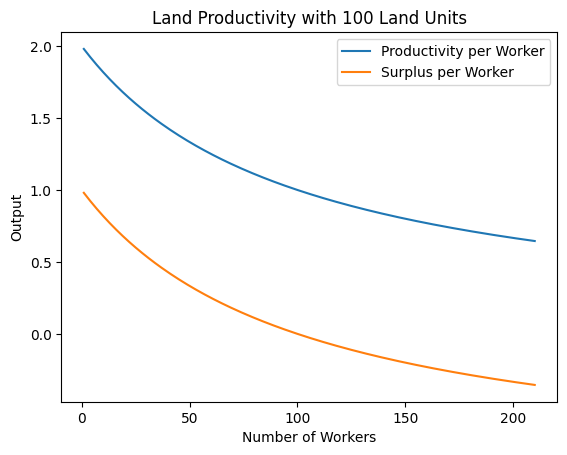

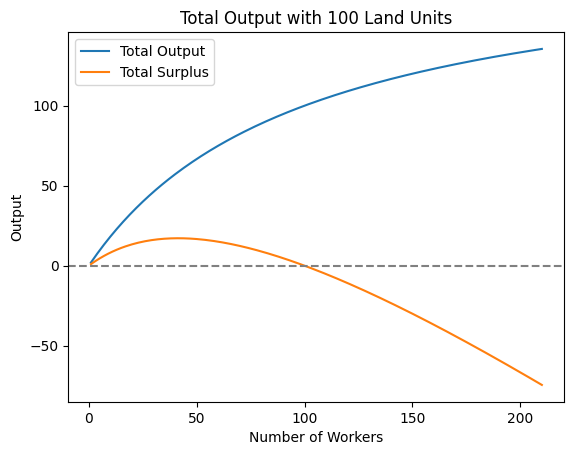

Surplus peaks at 41 workers with a surplus of 17.16
Zero crossing at 101 workers


C:\Users\white\AppData\Local\Temp\ipykernel_43836\2518650611.py:80: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


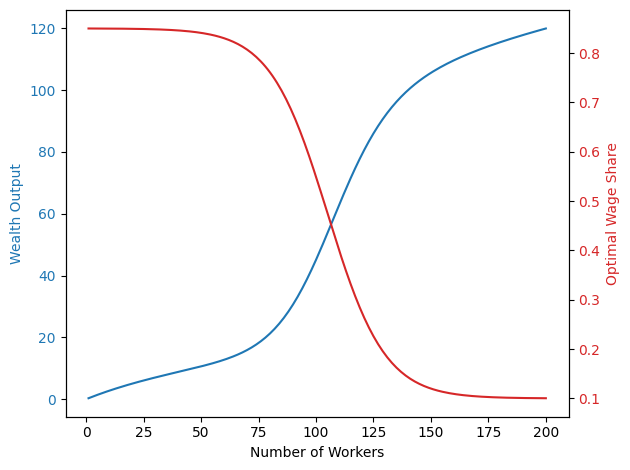

In [4]:
# Example usage and plotting
x_range = []
y_range_prod = []
y_range_rel_surplus = []
y_range_total = []
y_range_surplus = []

surplus_peak = 0
surplus_peak_value = 0
zero_crossing = 0
for x in range(210):
    land = 100
    workers = x + 1
    productivity = get_land_productivity(land, workers, base_productivity=2.0, saturation=1.0, exp=1.0)
    total_output = productivity * workers # Food per worker
    total_surplus = total_output - workers

    surplus_peak = workers if total_surplus > surplus_peak_value else surplus_peak
    surplus_peak_value = max(surplus_peak_value, total_surplus)
    zero_crossing = workers if total_surplus < 0 and zero_crossing == 0 else zero_crossing

    x_range.append(workers)
    y_range_prod.append(productivity)
    y_range_rel_surplus.append(total_surplus/workers)
    y_range_total.append(total_output)
    y_range_surplus.append(total_surplus)

x_range_elite_surplus = []
y_range_elite_optimal_wage = []
y_range_elite_wealth_output = []
for x in range(200):
    land_commoners = 20
    land_elites = 80
    commoners = x + 1

    optimal_wage = get_wage_share(commoners, jobs_count=land_elites+land_commoners, worker_owned_count=land_commoners, k=-8.0, d_crit=1.0)
    wealth_output = get_land_productivity(land_elites+land_commoners, commoners, base_productivity=2.0, saturation=1.0, exp=1.0) * (1 - optimal_wage) * commoners
    # optimal_wage, wealth_output = optimize_wage_share(land_elites, land_commoners, commoners, slaves=0, saturation=0.25, exp=3)
    x_range_elite_surplus.append(commoners)
    y_range_elite_optimal_wage.append(optimal_wage)
    y_range_elite_wealth_output.append(wealth_output)

plt.plot(x_range, y_range_prod, label="Productivity per Worker")
plt.plot(x_range, y_range_rel_surplus, label="Surplus per Worker")
plt.xlabel("Number of Workers")
plt.ylabel("Output")
plt.title("Land Productivity with 100 Land Units")
plt.legend()
plt.show()

plt.plot(x_range, y_range_total, label="Total Output")
plt.plot(x_range, y_range_surplus, label="Total Surplus")
plt.axhline(y=0, color='gray', linestyle='--') # zero line
plt.xlabel("Number of Workers")
plt.ylabel("Output")
plt.title("Total Output with 100 Land Units")
plt.legend()
plt.show()

print(f"Surplus peaks at {surplus_peak} workers with a surplus of {surplus_peak_value:.2f}")
print(f"Zero crossing at {zero_crossing} workers")

# Left axis: Wealth Output
# Right axis: Optimal Wage Share
fig, ax1 = plt.subplots()
color = 'tab:blue'
ax1.set_xlabel("Number of Workers")
ax1.set_ylabel("Wealth Output", color=color)
ax1.plot(x_range_elite_surplus, y_range_elite_wealth_output, label="Wealth Output", color=color)
ax1.tick_params(axis='y', labelcolor=color)

# Create a second y-axis for optimal wage share
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel("Optimal Wage Share", color=color)
ax2.plot(x_range_elite_surplus, y_range_elite_optimal_wage, label="Optimal Wage", color=color)
ax2.tick_params(axis='y', labelcolor=color)

fig.tight_layout()
fig.show()

In [5]:
print(y_range_elite_optimal_wage)

[0.8498173475952012, 0.8498021390253038, 0.8497856644743685, 0.8497678186232833, 0.8497484874021503, 0.8497275472650864, 0.8497048644052551, 0.8496802939052537, 0.8496536788176068, 0.8496248491696904, 0.849593620886967, 0.8495597946279394, 0.8495231545237035, 0.849483466814445, 0.8494404783746224, 0.8493939151179579, 0.8493434802726779, 0.8492888525167347, 0.8492296839619663, 0.8491655979753548, 0.8490961868246657, 0.8490210091348548, 0.8489395871406545, 0.8488514037197474, 0.8487558991898692, 0.8486524678520662, 0.8485404542611857, 0.8484191492034675, 0.8482877853598727, 0.848145532632524, 0.8479914931103403, 0.8478246956486618, 0.8476440900363779, 0.847448540722812, 0.8472368200754231, 0.8470076011382545, 0.846759449860066, 0.8464908167602369, 0.8462000279999004, 0.8458852758254121, 0.8455446083512448, 0.8451759186498109, 0.8447769331166783, 0.84434519908122, 0.8438780716351301, 0.8433726996545442, 0.8428260109959312, 0.8422346968516812, 0.8415951952586178, 0.8409036737617942, 0.8401

In [6]:
class Pop:
    def __init__(self, name, n):
        self.name = name
        self.population = n
        self.wealth = 0.0
        self.wealth_level = 0
        self.desired_wealth_level = 0.0
        self.taxes = 0.0
        self.government_benefits = 0.0

class Simulation:
    def __init__(self):
        self.population = 0.0
        self.total_wealth = 0.0
        self.pops = {}
        self.land_area = 1000  # total arable land
        self.food_production_per_land = 2.0  # food produced per unit land
        self.food_consumption_per_capita = 1.0  # food consumed per person
        self.productivity = 1.0  # base productivity of land
        self.wealth_per_land = 1.0  # wealth generated per unit land
        self.common_land = 800.0
        self.elite_land = 200.0

        self.food_production = 0.0
        self.food_consumption = 0.0
        self.food_shortage = 0.0

        self.wage_share = 0.0
        
        # Popular Immiseration
        # The metric that tracks how much misery the common people experience
        # Sources from food shortages, wealth inequality, and decreases in wealth
        self.population_ratio = 0.0
        self.popular_immiseration = 0.0

        # Elite Overproduction
        # The metric that tracks how much overproduction the elite experience (relative to job opportunities).
        # Jobs are based on elite land, state employment, and business opportunities. Added to this is a 1% population buffer to represent lower level elite positions 
        self.elite_job_opportunities = 0.0
        self.elite_excess = 0.0
        self.elite_overproduction = 0.0

        # Sociopolitical Instability
        # The metric that tracks how much sociopolitical instability there is. This is influenced by popular immiseration and elite overproduction.
        # It only starts affecting the simulation once it's above state capacity
        # (Once above state capacity) It decreases state revenues, increases death/demotion rates (particularly of the elite), and decreases productivity
        self.sociopolitical_instability = 0.0
        self.effective_instability = 0.0

        # State Capacity
        # The metric that tracks how much state capacity there is. This represents the state's ability to maintain order and provide public goods.
        # The state collects revenues from taxing the elite and commoners, but it also has expenses from maintaining order and providing elites jobs. 
        # If expenses exceed revenues, debt increases which reduces state capacity.
        # Revenues also decrease when sociopolitical instability increases above state capacity, as the state is less able to collect taxes and maintain order.
        # Once the state collapses debt is reset to 0 to represent default. This also allows the state to potentially recover if conditions improve enough after collapse.
        self.state_capacity = 1.0
        self.taxation_rate_commoners = 0.0
        self.taxation_rate_elites = 0.0
        self.revenue = 0.0
        self.expenses = 0.0
        self.state_jobs = 0.0
        self.debt = 0.0
        
        self.population_history = []
        self.wealth_history = []
        self.security_history = []
        self.wage_share_history = []
        self.inequality_history = []
        self.elite_ratio_history = []
        self.state_capacity_history = []

        self.revenue_history = []
        self.expenses_history = []
    
    def add_pop(self, name, n):
        pop = Pop(name, n)
        self.pops[name] = pop
        self.population += n

    def adjust_population(self, name, delta):
        if name not in self.pops:
            return
        
        self.pops[name].population = max(0.0, self.pops[name].population + delta)
        self.population = max(0.0, self.population + delta)
    
    # Positive: Elites get land from commoners. Negative: Elites give land to commoners.
    def land_transfer(self, land: float):
        if land == 0:
            return
        
        # Bound land to the amount of land available for transfer
        land = max(-self.elite_land, min(self.common_land, land))

        self.common_land -= land
        self.elite_land += land
    
    def social_mobility(self, pop: float, land_rate: float = 2.0):
        if pop == 0:
            return

        # Bound pop to the amount of population available for promotion
        pop = max(-self.pops["Elites"].population, min(self.pops["Commoners"].population, pop))

        self.pops["Commoners"].population -= pop
        self.pops["Elites"].population += pop

        # Portion of land goes with the promoted/demoted pops. Land rate determines disproportionality of land transfer.
        if land_rate == 0:
            return

        if pop > 0:
            land_transfer_amount = (pop / self.pops["Commoners"].population) * self.common_land * land_rate if self.pops["Commoners"].population > 0 else 0.0
        else:
            land_transfer_amount = -1 * (pop / self.pops["Elites"].population) * self.elite_land / land_rate if self.pops["Elites"].population > 0 else 0.0
        self.land_transfer(land_transfer_amount)

    def get_inequality(self):
        elite_per_capita = self.pops["Elites"].wealth / self.pops["Elites"].population if self.pops["Elites"].population > 0 else 0.0
        commoner_per_capita = self.pops["Commoners"].wealth / self.pops["Commoners"].population if self.pops["Commoners"].population > 0 else 0.0

        return elite_per_capita / commoner_per_capita if commoner_per_capita > 0 else float('inf')
    
    def get_elite_ratio(self):
        elite_population = self.pops["Elites"].population if "Elites" in self.pops else 0.0
        common_population = self.pops["Commoners"].population if "Commoners" in self.pops else 0.0

        return elite_population / common_population if common_population > 0 else float('inf')
    
    def default_setup(self):
        #self.add_pop("Slaves", 200, 0)
        self.add_pop("Commoners", 300)
        #self.add_pop("Urbanites", 200, 0)
        self.add_pop("Elites", 4)

        self.taxation_rate_commoners = 0.1
        self.taxation_rate_elites = 0.2

        self.land_jobs = get_job_capacity(self.land_area, method_applied=self.productivity-1, method_exponent=0.95)
        self.wage_share = get_wage_share(self.pops["Commoners"].population, self.land_jobs, self.land_jobs * (self.common_land/self.land_area))
        self.micro_economy_step()
        self.state_capacity_step()
        for pop in self.pops.values():
            pop.wealth_level = get_wealth_level(pop.population, pop.wealth + pop.government_benefits - pop.taxes)
            pop.desired_wealth_level = pop.wealth_level
    
    def micro_economy_step(self):
        # Commoner Allocation
        self.land_jobs = get_job_capacity(self.land_area, method_applied=self.productivity-1, method_exponent=0.95)
        
        commoner_land_pull = self.productivity * self.land_jobs * (self.common_land / self.land_area)
        elite_land_pull = self.productivity * self.land_jobs * (self.elite_land / self.land_area) * ((1+self.wage_share) / 2.0)
        
        self.land_pull = commoner_land_pull + elite_land_pull
        self.total_commoner_pull = self.land_pull # for now, we can add other pulls (like urban jobs) to this in the future

        self.commoners_on_land = self.pops["Commoners"].population * (self.land_pull / self.total_commoner_pull) if self.total_commoner_pull > 0 else 0.0

        # Production
        prod_final = self.productivity
        land_prod = get_land_productivity(self.land_area, self.commoners_on_land, base_productivity=prod_final) * self.commoners_on_land
        
        # Wealth Allocation
        # From Work
        work_value = land_prod * self.wealth_per_land
        self.pops["Commoners"].wealth = work_value * self.wage_share
        
        # From Ownership
        self.pops["Commoners"].wealth += work_value * (1 - self.wage_share) * (self.common_land / self.land_area) 
        self.pops["Elites"].wealth = work_value * (1 - self.wage_share) * (self.elite_land / self.land_area) 
        self.total_wealth = work_value
        
        # Food Calculation
        self.food_production = land_prod * self.food_production_per_land
        self.food_consumption = sum(pop.population * self.food_consumption_per_capita for pop in self.pops.values())
        self.food_shortage = max(0.0, self.food_production - self.food_consumption) / self.food_consumption if self.food_consumption > 0 else 0.0

    def popular_immiseration_step(self):
        popular_immiseration = self.food_shortage * 0.5 + max(0.0, (self.pops["Commoners"].desired_wealth_level - self.pops["Commoners"].wealth_level) * 0.2)
        
        # Any shortage causes misery
        if self.food_shortage > 0.0:
            popular_immiseration += 0.1

        # Populace become content with their desired wealth level (also helps get PI to 0)
        if self.pops["Commoners"].wealth_level > self.pops["Commoners"].desired_wealth_level:
            popular_immiseration -= 0.1
        
        self.popular_immiseration = min(max(0.0, self.popular_immiseration * 0.5 + popular_immiseration * 0.5), 1.0) # smoothing
        self.population_ratio = self.population / (self.land_area * self.productivity) if (self.land_area * self.productivity) > 0 else float('inf')

    def elite_overproduction_step(self):
        buffer = 0.005 * self.population
        self.elite_job_opportunities = self.elite_land * 0.01 * self.productivity + self.state_jobs + buffer
        self.elite_excess = max(0.0, self.pops["Elites"].population - self.elite_job_opportunities + self.state_jobs)
        self.elite_overproduction = max(0.0, self.pops["Elites"].population - self.elite_job_opportunities) / (self.elite_job_opportunities + 1e-8)
        
    def sociopolitical_instability_step(self):
        self.sociopolitical_instability = self.popular_immiseration * 0.5 + self.elite_overproduction * 0.5
        effective_instability = min(max(0.0, self.sociopolitical_instability - self.state_capacity), 1.0)
        if self.sociopolitical_instability < self.state_capacity:
            effective_instability = -0.1

        self.effective_instability = self.effective_instability * 0.5 + effective_instability * 0.5 # smoothing
    
    def state_capacity_step(self):
        repression = self.sociopolitical_instability - self.effective_instability
        effective_taxation_rate_commoners = self.taxation_rate_commoners * (1.0 - self.effective_instability)
        effective_taxation_rate_elites = self.taxation_rate_elites * (1.0 - self.effective_instability)
        
        self.pops["Commoners"].taxes = effective_taxation_rate_commoners * self.pops["Commoners"].wealth
        self.pops["Elites"].taxes = effective_taxation_rate_elites * self.pops["Elites"].wealth

        elite_desired_wealth = wealth_req[round(self.pops["Elites"].desired_wealth_level)]
        self.pops["Elites"].government_benefits = self.state_jobs * elite_desired_wealth

        interest = min(self.debt * 0.05, self.revenue * self.state_capacity) # State debt payments is 1/n^2 of its capacity. 
        # This means lower capacity is able to pay less, which represents the difficulty of paying debt during times of crisis. 
        # It also means that if the state collapses (capacity goes to 0), it effectively defaults on its debt.
        # It also makes it easier for the state to recover from collapse if conditions improve, as the debt burden is reduced during collapse.

        self.revenue = self.taxation_rate_commoners * self.pops["Commoners"].wealth + self.taxation_rate_elites * self.pops["Elites"].wealth
        self.expenses = self.state_jobs * elite_desired_wealth + interest + repression * self.population * elite_desired_wealth * 0.1
        

    def adjustments_step(self):
        # Government adjustments
        self.state_jobs = (self.pops["Elites"].population * 0.05 + self.elite_excess) * self.state_capacity # Military + State tries to absorb excess elite population

        net_budget = self.revenue - self.expenses
        if net_budget < 0:
            if self.debt * 0.05 < self.revenue * self.state_capacity:
                self.debt += -net_budget
        else:
            self.debt = max(0.0, self.debt - net_budget) # Pay down debt if there's a surplus

        if self.state_capacity > 0.0:
            # Adjust taxes based on revenues
            if self.revenue < self.expenses:
                self.taxation_rate_commoners = min(0.25, self.taxation_rate_commoners + 0.01)
                self.taxation_rate_elites = min(0.5, self.taxation_rate_elites + 0.02)
            elif self.revenue > self.expenses * 1.2: # If there's a large surplus, consider lowering taxes
                self.taxation_rate_commoners = max(0.05, self.taxation_rate_commoners - 0.01)
                self.taxation_rate_elites = max(0.1, self.taxation_rate_elites - 0.02)
        
        debt_payment_capacity = self.revenue * self.state_capacity
        debt_payment = self.debt * 0.05

        state_capacity_change = 0.1 + 0.1 * (net_budget / (self.expenses + 1e-8)) - 0.1 * (debt_payment * 2 / (debt_payment_capacity + 1e-8) - 1)
        self.state_capacity = max(0.0, min(1.0, self.state_capacity + state_capacity_change))

        # Wage Adjustment
        self.wage_share = get_wage_share(self.pops["Commoners"].population, self.land_jobs, self.land_jobs * (self.common_land/self.land_area))

        # Goods Shortages and Population Growth
        for pop in self.pops.values():
            pop.wealth_level = get_wealth_level(pop.population, pop.wealth - pop.taxes + pop.government_benefits) # Wealth level is based on disposable wealth after taxes and benefits
            shortage_modifier = get_shortage_modifier(pop.wealth_level, self.food_shortage)
            population_change = pop.population * 0.01 + 0.001 * pop.wealth_level  # Base growth plus wealth-based growth
            if shortage_modifier > 0.0:
                population_change -= pop.population * shortage_modifier * 0.1  # 10% of the effective shortage impacts population
            if pop.name == "Elites":
                population_change -= self.effective_instability * pop.population * 0.05 # Elites are more affected by instability, which can cause death or demotion
            self.adjust_population(pop.name, population_change)
        
        # Elites downgrade when they're poor
        if self.get_inequality() < 5.0:
            rate = -0.2 * (5.0 - self.get_inequality())
            self.social_mobility(pop=rate * self.pops["Elites"].population, land_rate=2.0)

        # New elites form from commoners
        if self.common_land > 0.0 and self.effective_instability < 0.25:
            rate = 0.01 * self.get_inequality()
            self.social_mobility(pop=rate * (self.pops["Commoners"].population * 0.01 + self.pops["Elites"].population), land_rate=20.0)

            if self.elite_job_opportunities - self.state_jobs > self.pops["Elites"].population:
                self.social_mobility(pop=self.elite_job_opportunities * 0.01, land_rate=20.0)

        # Correct values in case of issues
        self.population = sum(pop.population for pop in self.pops.values())
        
    def record_history(self):
        total_population = sum(pop.population for pop in self.pops.values())
        total_wealth = sum(pop.wealth for pop in self.pops.values())
        security = 1 - self.effective_instability
        inequality = self.get_inequality()
        elite_ratio = self.get_elite_ratio()

        self.population_history.append(total_population)
        self.wealth_history.append(total_wealth)
        self.security_history.append(security)
        self.wage_share_history.append(self.wage_share)
        self.inequality_history.append(inequality)
        self.elite_ratio_history.append(elite_ratio)
        self.state_capacity_history.append(self.state_capacity)

        self.revenue_history.append(self.revenue)
        self.expenses_history.append(self.expenses)

    def step(self, step=0, verbose=False):
        self.micro_economy_step()
        self.popular_immiseration_step()
        self.elite_overproduction_step()
        self.sociopolitical_instability_step()
        self.state_capacity_step()
        self.adjustments_step()
        self.record_history()

        if verbose:
            print(f"Step {step}: Population: {self.population:.0f}, Wealth: {self.total_wealth:.2f}, Food Shortage: {self.food_shortage:.2%}, Wage Share: {self.wage_share:.2%}, Inequality: {self.get_inequality():.2f}, Elite Ratio: {self.get_elite_ratio():.4f}, State Capacity: {self.state_capacity:.2f}, Sociopolitical Instability: {self.sociopolitical_instability:.2f}")


NEXT: 
Add in the state (state land - shares workers with elite land)
Add in elite extraction bonus/malus (two different wages - one for equalization, the other for extraction)
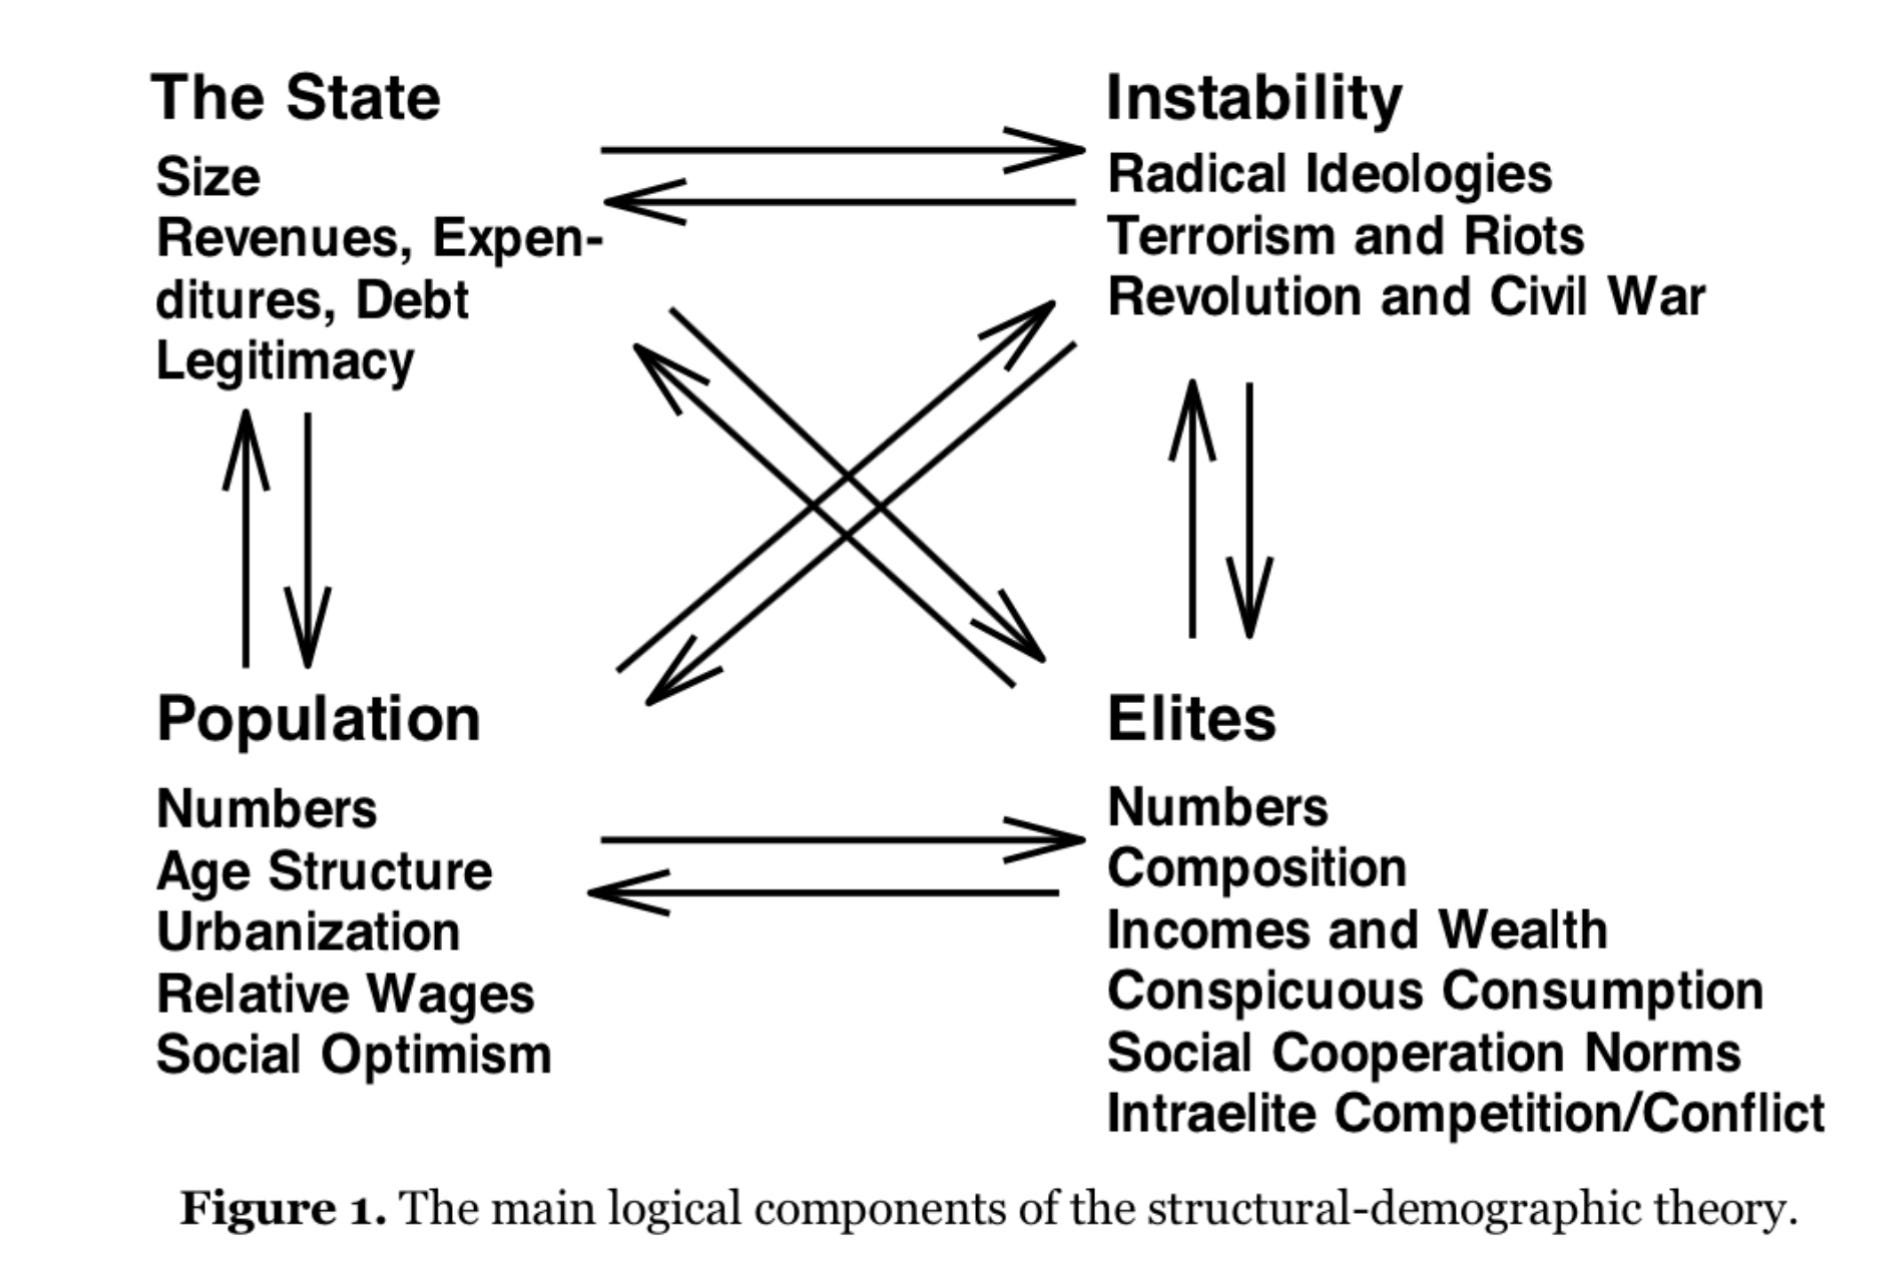

Investment:
    A portion of wealth in excess of expected wealth level rounded up gets put into an investment pool separated by pop type
    Those pops then use that money to invest in production & capital
    Pops in a location might decide to locally fund certain nonproductive enterprises by themselves depending on conditions (education, housing, security)

Popular immiseration:
    desired_wealth = 20-year moving average of actual wealth per commoner
        desired_new = desired_old + 0.05 * (current wealth - desired_old)
    base_immiseration = max(0, desired_wealth - current_wealth_per_commoner) * 0.2
    spike from shortages: +1.0 from 100% shortage
    Final = clamp (0-1) and smooth

Elite Overproduction:
    elite_job_opportunities = (total_elite_positions) + buffer
        elite_positions = elite_land / avg_elite_land_per_capita + state_employment_slots + business_slots
        buffer = 1 % of total population
    
    elite_overproduction = max(0, (elite_numbers - elite_job_opportunities) / elite_job_opportunities)

Sociopolitical Instability
    Instability = immiseration + elite overproduction
    Father and son pulse: Add/remove every 20ish years

State Capacity
    Revenue = (commoner_wealth * tax_rate_common) + (elite_surplus * tax_rate_elite)
    Spending = (elite_job_opportunities * cost_per_elite) + (military + repression) + (debt_service)
    Balance = Revenue - Spending
    Debt = Debt_old + max(0, -Annual_balance)
    State_capacity_new = (1-Debt/GDP_proxy) + (1-immiseration)


Step 0: Population: 292, Wealth: 230.77, Food Shortage: 51.82%, Wage Share: 84.94%, Inequality: 4.37, Elite Ratio: 0.0071, State Capacity: 1.00, Sociopolitical Instability: 0.16
Step 1: Population: 280, Wealth: 224.90, Food Shortage: 53.93%, Wage Share: 84.93%, Inequality: 6.01, Elite Ratio: 0.0087, State Capacity: 1.00, Sociopolitical Instability: 0.14
Step 2: Population: 269, Wealth: 217.47, Food Shortage: 55.16%, Wage Share: 84.94%, Inequality: 5.43, Elite Ratio: 0.0102, State Capacity: 1.00, Sociopolitical Instability: 0.16
Step 3: Population: 257, Wealth: 210.01, Food Shortage: 56.40%, Wage Share: 84.94%, Inequality: 4.98, Elite Ratio: 0.0117, State Capacity: 1.00, Sociopolitical Instability: 0.18
Step 4: Population: 246, Wealth: 202.54, Food Shortage: 57.65%, Wage Share: 84.94%, Inequality: 4.62, Elite Ratio: 0.0133, State Capacity: 1.00, Sociopolitical Instability: 0.19
Step 5: Population: 234, Wealth: 195.07, Food Shortage: 58.88%, Wage Share: 84.95%, Inequality: 4.51, Elite Ra

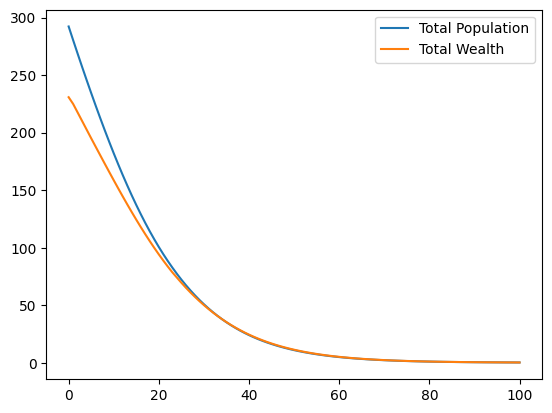

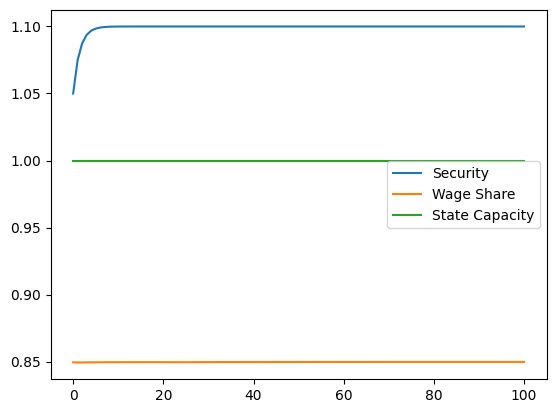

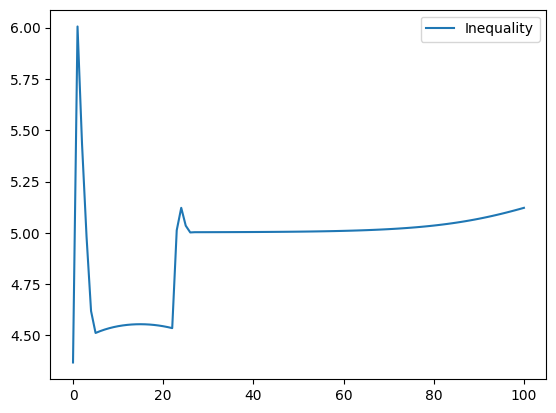

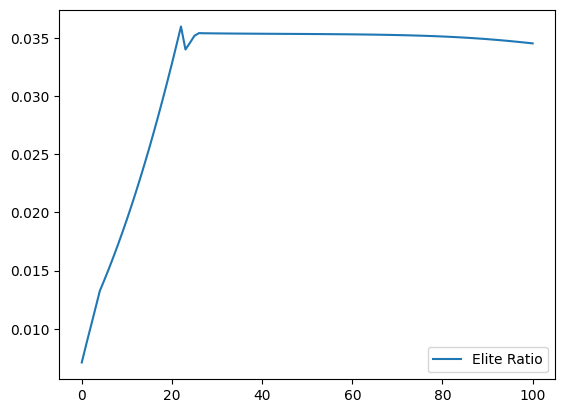

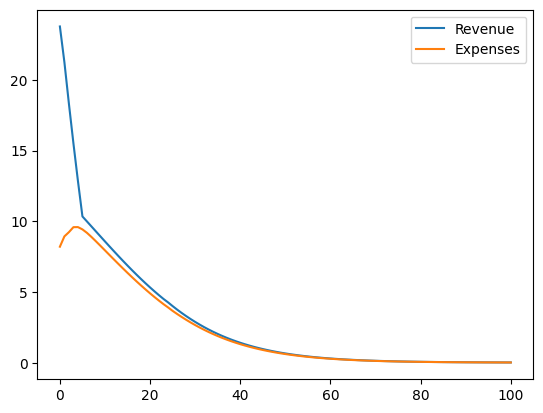

In [7]:
sim = Simulation()
sim.default_setup()
random.seed(42)
for step in range(101):
    sim.step(step=step, verbose=True)

plt.plot(sim.population_history, label="Total Population")
plt.plot(sim.wealth_history, label="Total Wealth")
plt.legend()
plt.show()

plt.plot(sim.security_history, label="Security")
plt.plot(sim.wage_share_history, label="Wage Share")
plt.plot(sim.state_capacity_history, label="State Capacity")
plt.legend()
plt.show()

plt.plot(sim.inequality_history, label="Inequality")
plt.legend()
plt.show()

plt.plot(sim.elite_ratio_history, label="Elite Ratio")
plt.legend()
plt.show()

plt.plot(sim.revenue_history, label="Revenue")
plt.plot(sim.expenses_history, label="Expenses")
plt.legend()
plt.show()

In [8]:
# Simplified version of Secular Cycles with just the core feedback loops, to test the dynamics of the model and see if it can generate realistic cycles of growth and collapse.
# It has four main variables (from 0.0 to 1.0):
# P - Population: Population relative to carrying capacity. Affected by food shortages and wealth levels. Below 0.5 is below carrying capacity, above 0.5 is above carrying capacity.
# E - Elite Overproduction: The level of elite overproduction relative to elite job opportunities. Affected by population and elite land. Above 0.0 means elites are overproducing relative to job opportunities.
# U - Sociopolitical Instability: The level of sociopolitical instability. Its effect is U^2. 0.0 means stable peace, 1.0 means civil war.
# S - State Capacity: How much the state is able to act, coerce the population, and provide public goods. 1.0 means strong and stable state, 0.0 means de-facto anarchy
#
# P:
# Supply curve to State Capacity
# Kept low by U
# E:
# Increases when P is high
# Shrinks via U
# U:
# Increases when E is high
# Shrinks when S is high
# Spikes every 40-50 years (father son cycle)
# S:
# Increases when P is high
# Decreases when U is high
# Decreases when E is high (state employing overproduced elites)
#
# Rotating Influences:
# P, S naturally grows
# P increases E (more population creates more elites)
# E decreases S (overproduced elites require state resources and create instability)
# P, E, and less S increase U (overpopulation, elite overproduction, and low state capacity all contribute to instability)
# U decreases S, E, and P

class SimpleSim:
    def __init__(
            self, 
            P=0.4, # Starting Population
            E=0.1, # Starting Elite Overproduction
            S=0.5, # Starting State Capacity
            dP_mult=1.0, # Growth multipliers
            dE_mult=1.0, 
            dS_mult=1.0, 
            dP_nmult=0.5, # Shrink multipliers (when growth is negative)
            dE_nmult=0.5, 
            dS_nmult=2.0
        ):
        self.P = P  # Population
        self.E = E  # Elite Overproduction
        self.U = 0.0  # Sociopolitical Instability
        self.U_e = 0.0  # Effective Instability (instability above state capacity)
        self.S = S  # State Capacity
        self.instability_memory = 0.0 # Memory of past instability to create inertia in the system
        
        self.phase = 0 # 0 = prosperity, 1 = strain, 2 = fracture
        
        # Random value multipliers that change every 10 steps since adjusting randomness every step cancels out the effect.
        self.P_rand = 0.0
        self.E_rand = 0.0
        self.U_rand = 0.0
        self.S_rand = 0.0

        self.P_history = []
        self.E_history = []
        self.U_history = []
        self.U_e_history = []
        self.S_history = []
        self.phase_history = []

        # Multipliers
        self.dP_mult = dP_mult
        self.dE_mult = dE_mult
        self.dS_mult = dS_mult
        self.dP_nmult = dP_nmult
        self.dE_nmult = dE_nmult
        self.dS_nmult = dS_nmult
    
    def step(self, t, randomness=0.0):

        # Population growth is based on a logistic growth model with carrying capacity influenced by state capacity and effective instability.
        carrying_cap = min(max(0.5 + self.S**2 - self.U_e * 1.0, 0.0), 1.0)
        dP = (self.P + 0.1) * (carrying_cap - self.P)
        if dP > 0:
            dP *= self.P * (1.1 - self.P) / 1.1 # Population grows slower as it approaches carrying capacity
            dP *= self.dP_mult
        else:
            dP *= (self.P+0.1)/1.1 # Population shrinks slower as it approaches 0.0
            dP *= self.dP_nmult

        
        # Elite overproduction increases with population pressure (so long as the state exists)
        # It decreases with effective instability as well as low population pressure representing how elites are the targets of violence and also high wages squeezing elite wealth.
        dE = (self.P**2 * max(0.0, self.S - self.U_e) - self.U_e**2 + min(0.0, self.P - 0.5) * 0.25)
        if dE > 0:
            dE *= (1.1 - self.E)/1.1
            dE *= self.dE_mult
        else:
            dE *= (self.E+0.2)/1.2
            dE *= self.dE_nmult

        # Sociopolitical instability increases with elite overproduction and population pressure, and decreases with state capacity. 
        # TODO: It also has periodic spikes every 40-50 years to represent father-son cycles of violence.
        #dU = (self.E - self.S + (t % 50 < 5) - 0.8 * self.U) * dU_mult
        immiseration = max(0.0, self.P - carrying_cap * 0.5) * 2 + self.E * 0.2 # Immiseration starts when population exceeds 50% of carrying capacity
        p_mobilization = min(1.0, immiseration + math.sqrt(self.instability_memory) * 0.5) # Population mobilization is based on current immiseration and memory of past instability
        e_mobilization = min(1.0, self.E + math.sqrt(self.instability_memory) * 0.5)
        unrest = p_mobilization * e_mobilization * (1 - self.S)
        dU = 0 #(-0.5 + 1 * (t % 50 < 5) - self.S) * dU_mult # Father-son cycles added to unrest equation

        # State capacity increases with population pressure and decreases with elite overproduction and sociopolitical instability. It also has a baseline growth to represent the desire to have a state.
        dS = (0.0 + self.P*(1.0 - self.U_e) - self.U_e**2 - self.E*(self.S+0.1))
        if dS > 0:
            dS *= (1.5 - self.S)/1.5
            dS *= self.dS_mult
        else:
            dS *= (self.S+0.2)/1.2
            dS *= self.dS_nmult

        # Randomness to represent unmodeled factors and add variability to the system
        if randomness > 0.0:
            if t % 10 == 0: # Adjust randomness every 10 steps to create periods of stability and instability
                self.P_rand = random.uniform(-randomness, randomness) + 1
                self.E_rand = random.uniform(-randomness, randomness) + 1
                self.U_rand = random.uniform(-randomness, randomness) + 1
                self.S_rand = random.uniform(-randomness, randomness) + 1
            
            dP *= self.P_rand
            dE *= self.E_rand
            unrest *= self.U_rand
            dS *= self.S_rand

        # Update variables with some smoothing
        self.P = max(0.0, min(1.0, self.P + dP * 0.1))
        self.E = max(0.0, min(1.0, self.E + dE * 0.1))
        self.U = max(0.0, min(1.0, self.U + dU * 0.1))
        self.S = max(0.0, min(1.0, self.S + dS * 0.1))

        self.U_e = max(0.0, min(unrest + self.U, 1.0)) # Effective instability is instability above 0.5 * state capacity
        if self.U_e > self.instability_memory:
            self.instability_memory = self.U_e
        else:
            self.instability_memory *= 0.95 # Instability memory decays over time, creating inertia in the system
            self.instability_memory = max(self.U_e, self.instability_memory-0.02) # Instability memory has a baseline decay to prevent it from getting stuck at high levels forever
        
        # Phase transitions
        if self.phase == 0 and (self.U > 0.1 or self.E > 0.5 or self.P > 0.7):
            self.phase = 1
        elif self.phase == 1 and (self.U_e > 0.5 or self.S < 0.5 or (dE < 0 and dP < 0)):
            self.phase = 2
        elif self.phase == 2 and (self.U_e < 0.05 and dP > 0 and self.S > 0.2):
            self.phase = 0

        # Record history
        self.P_history.append(self.P)
        self.E_history.append(self.E)
        self.U_history.append(self.U)
        self.U_e_history.append(self.U_e)
        self.S_history.append(self.S)
        self.phase_history.append(self.phase)

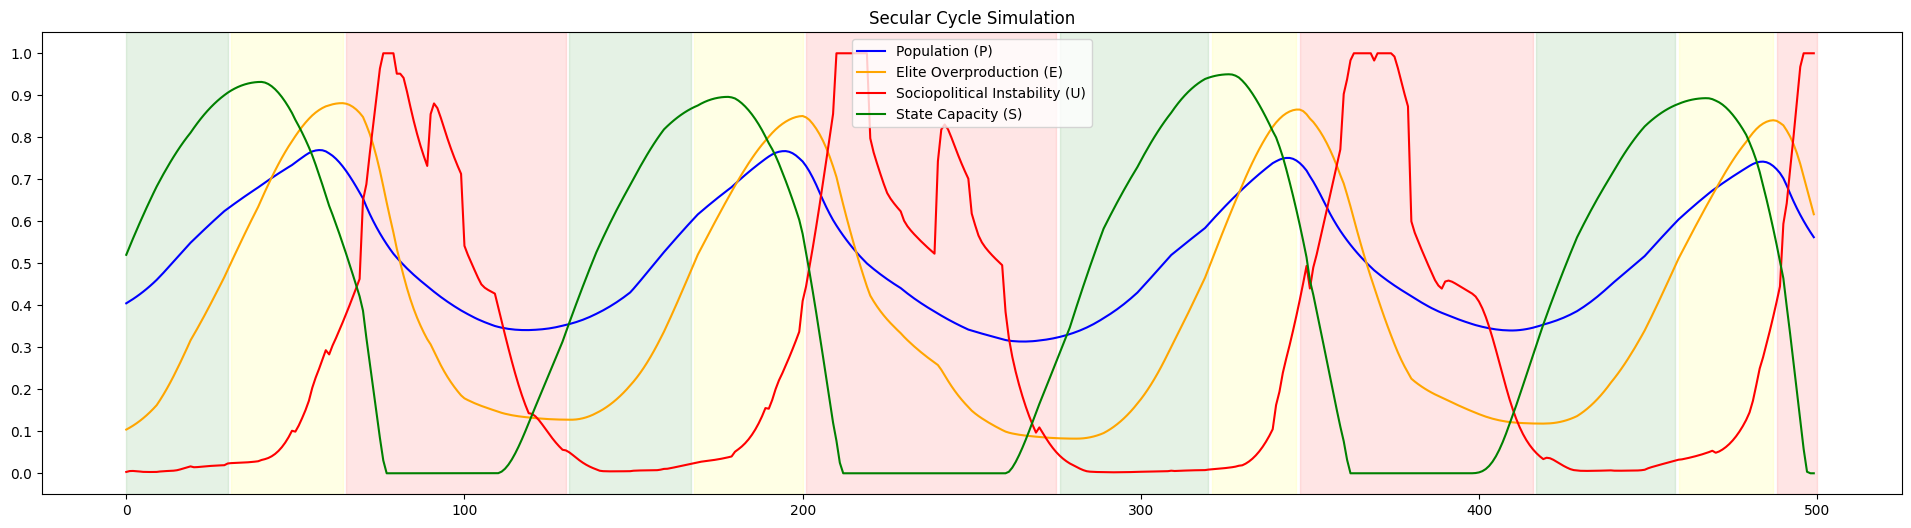

In [9]:
def plot_phase_space(phase_history=[]):
    # build phase space plot to color the background based on the phase of the system
    # Phase 0 = prosperity (green), Phase 1 = strain (yellow), Phase 2 = fracture (red)
    phase_types = []
    phase_starts = [0]
    phase_ends = []
    for x in range(0, len(phase_history)-1):
        if phase_history[x] != phase_history[x+1]:
            phase_types.append(phase_history[x])
            phase_ends.append(x)
            phase_starts.append(x+1)
    phase_types.append(phase_history[-1])
    phase_ends.append(len(phase_history))
    
    for x in range(len(phase_types)):
        if phase_types[x] == 0:
            plt.axvspan(phase_starts[x], phase_ends[x], color='green', alpha=0.1)
        elif phase_types[x] == 1:
            plt.axvspan(phase_starts[x], phase_ends[x], color='yellow', alpha=0.1)
        elif phase_types[x] == 2:
            plt.axvspan(phase_starts[x], phase_ends[x], color='red', alpha=0.1)

def plot_simulation(
    P_history, E_history, U_history, S_history, phase_history
):
    # Implementation for plotting the simulation results
    plt.figure(figsize=(24, 6))
    plt.yticks([0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0])
    plt.plot(P_history, label="Population (P)", color='blue')
    plt.plot(E_history, label="Elite Overproduction (E)", color='orange')
    plt.plot(U_history, label="Sociopolitical Instability (U)", color='red')
    plt.plot(S_history, label="State Capacity (S)", color='green')
    plot_phase_space(phase_history)
    plt.legend()
    plt.title("Secular Cycle Simulation")
    plt.show()
    pass

random.seed(42)

simple_sim = SimpleSim(
    P=0.4,
    E=0.1,
    S=0.5,
    dP_mult=1.0,
    dE_mult=1.0,
    dS_mult=1.0,
    dP_nmult=0.5,
    dE_nmult=0.5,
    dS_nmult=2.0
)
for t in range(500):
    simple_sim.step(t, randomness=0.2)

plot_simulation(    
    simple_sim.P_history, simple_sim.E_history, simple_sim.U_e_history, simple_sim.S_history, simple_sim.phase_history
)

In [10]:
def get_wage(
        a,              # base wage level
        alpha,          # coefficient for GDP term 
        beta,           # coefficient for labor term
        gamma,          # coefficient for cultural term
        gdp,            # GDP of area/country
        population,     # Population of area/country
        labor_d,        # Labor demand (GDP / productivity)
        labor_s,        # Labor supply (population * labor participation rate)
        culture         # Cultural factor that affects wage levels
    ):
    gdp_term = (gdp / (population + 1e-8)) ** alpha
    labor_term = (labor_d/labor_s + 1e-8) ** beta
    culture_term = (culture + 1e-8) ** gamma
    return a * gdp_term * labor_term * culture_term

print(get_wage(
    a=1.0,
    alpha=1.0,
    beta=1.0,
    gamma=1.0,
    gdp=1000,
    population=100,
    labor_d=80,
    labor_s=80,
    culture=1.0
))

10.000000199


In [11]:
# Carrying Capacity -> Increase in Population -> 
# Reduction of wages (population pressure is highly correlated to inverse wages) -> 
# increase of social mobility into elites + MMP from low wages -> elite numbers -> 
# elite overproduction -> state income stress for supporting elites -> 
# falling elite income + rise in conspicuous consumption (so the barrier to being considered an elite is higher) -> 
# elite fragmentation and EMP -> falling state legitimacy as it fails to pay elites -> fall in state capacity -> 
# increase in PSI -> Instability -> Elite, Population mortality, erosion of state capacity -> more violence -> 
# drop in population & elites -> increase of wages -> decrease of elite incomes + downward mobility -> lower sustained violence -> 
# State comes back -> Elite overproduction stops -> Elite fragmentation stops -> violence stops -> population allowed to grow again.

class FinalSim:
    def __init__(
            self, 
            P=0.4, # Starting Population
            E=0.1, # Starting Elite Overproduction
            S=0.5, # Starting State Capacity
            dP_mult=1.0, # Growth multipliers
            dE_mult=1.0, 
            dS_mult=1.0, 
            dP_nmult=1.0, # Shrink multipliers (when growth is negative)
            dE_nmult=1.0, 
            dS_nmult=1.0
        ):
        self.P = P  # Population
        self.E = E  # Elite Overproduction
        self.U = 0.0  # Sociopolitical Instability
        self.U_e = 0.0  # Effective Instability (instability above state capacity)
        self.S = S  # State Capacity
        self.instability_memory = 0.0 # Memory of past instability to create inertia in the system
        
        self.phase = 0 # 0 = prosperity, 1 = strain, 2 = fracture
        
        # Random value multipliers that change every 10 steps since adjusting randomness every step cancels out the effect.
        self.P_rand = 0.0
        self.E_rand = 0.0
        self.U_rand = 0.0
        self.S_rand = 0.0

        self.P_history = []
        self.E_history = []
        self.U_history = []
        self.U_e_history = []
        self.S_history = []
        self.phase_history = []

        # Multipliers
        self.dP_mult = dP_mult
        self.dE_mult = dE_mult
        self.dS_mult = dS_mult
        self.dP_nmult = dP_nmult
        self.dE_nmult = dE_nmult
        self.dS_nmult = dS_nmult

        # Economy
        self.max_birth = 0.04
        self.min_birth = 0.015
        self.death_base = 0.01
        self.child_mortality = 0.4
        self.k_famine = 0.1
        self.k_disease = 0.1
        self.k_war = 0.05
        self.land_area = 1.0
        self.population = 0.6
        self.elites = 0.006

    def get_birth_rate(self, P, carrying_cap, security=1.0, start_decline=0.75, end_decline=1.5):
        # High fertility when well under cap (resources abundant, early marriage etc.), gradual decline as density rises. Still significant births beyond carrying cap
        rel = P / max(carrying_cap * security, 1e-8) # Low security has the effect of reducing carrying capacity when it comes to births
        t = np.clip((rel - start_decline) / (end_decline - start_decline), 0.0, 1.0)
        t = t * t * (3 - 2 * t)  # Smoothstep interpolation for a gradual transition

        return max(self.max_birth - (self.max_birth - self.min_birth) * t, self.min_birth)
    
    def get_death_rate(self, P, carrying_cap, birth_rate, famine_severity=0.0, disease_severity=0.0, war_severity=0.0):
        rel = P / max(1e-8, carrying_cap)

        base_death = self.death_base + self.child_mortality * birth_rate

        famine_excess = rel ** 1.2 * famine_severity ** 1.25 * self.k_famine
        disease_excess = rel ** 1.2 * disease_severity * self.k_disease * (1 + famine_severity ** 1.25)  # Disease worsens with famine
        war_excess = rel ** 1.2 * war_severity * self.k_war  # War increases death rate
        excess = famine_excess + disease_excess + war_excess

        return base_death + excess
    
    def step(self, t, randomness=0.0):

        # Population growth is based on a logistic growth model with carrying capacity influenced by state capacity and effective instability.
        # carrying_cap = min(max(0.5 + self.S**2 - self.U_e * 1.0, 0.0), 1.0)
        # dP = (self.P + 0.1) * (carrying_cap - self.P)
        # if dP > 0:
        #     dP *= self.P * (1.1 - self.P) / 1.1 # Population grows slower as it approaches carrying capacity
        #     dP *= self.dP_mult
        # else:
        #     dP *= (self.P+0.1)/1.1 # Population shrinks slower as it approaches 0.0
        #     dP *= self.dP_nmult


        # Population Growth
        carrying_cap = self.land_area
        birth_rate = self.get_birth_rate(self.population, carrying_cap, security=max(0.5,self.S-self.U_e))
        death_rate = self.get_death_rate(self.population, carrying_cap, birth_rate, famine_severity=0.0, disease_severity=0.0, war_severity=self.U_e)
        self.population += (birth_rate - death_rate) * self.population
        dP = (birth_rate - death_rate)

        # Effective wages
        # TODO: Implement a more complex wage model that takes into account wealth, labor supply/demand, and cultural factors.
        w = 1.0 - self.P  # Inverse of population pressure (high population = low wages, low population = high wages)
        w_inverse = w ** -1  # Inverse relative wage
        
        # Elite overproduction increases with population pressure (so long as the state exists)
        # How elite numbers themselves grow:
        # de/dt ~= u0 * e * (w0 - w ) / w
        # u0 = mobility responsiveness (how quickly elites respond to changes in wages)
        # w0 = point where social mobility is zero (wage level where elites are neither gaining nor losing members, wages above w0 reduce elites, below increase elites)
        # w = commoner wages
        # When commoner wages are low, more people try to climb into the elite, so elite numbers expand. Key feedback that links popular & elite departments
        # Elites are also teh target in instability, so they are pruned when instability is high. This is a slow attrition, not a sharp crash, so elites persist into the depression.
        elite_positions = (1 + self.S) * self.population * 0.01 # 2% of the population can be elites
        elite_wage = 0.5
        if self.elites < elite_positions:
            elite_wage = 0.5 + 0.5 * (self.elites / elite_positions) # When elites are below the number of positions, their relative income is higher, so they are less likely to be pruned
        else:
            elite_wage = 0.5 - 0.1 * ((self.elites - elite_positions) / elite_positions) # When elites are above the number of positions, their relative income is lower, so they are more likely to be pruned

        e_social_mobility = (self.elites) * 0.02 * (elite_wage - w) / w
        if e_social_mobility < 0:
            e_social_mobility *= 0.5 # Social mobility is slower when elites are losing members
        e_attrition = self.elites * 0.05 * self.U_e
        self.elites += e_social_mobility - e_attrition
        dE = (e_social_mobility - e_attrition) / max(self.elites, 1e-8)

        # Sociopolitical instability increases with elite overproduction and population pressure, and decreases with state capacity. 
        # TODO:
        # MMP (Mass Mobilization Potential) = W^-1 * (N(urb) / N) * A(20-29)
        # W^-1 = Inverse relative wage (real worker wage / GDP per capita) -> high wages = low unrest, low wages = high unrest
        # N(urb) / N = Urbanization rate (urban population / total population) -> high urbanization = high unrest, low urbanization = low unrest. 
        #       Rural misery is much harder to turn into mass political action. High urbanization dramatically increases the potential for unrest.
        # A(20-29) = Age structure (population aged 20-29 / total population) -> high proportion of young adults = high unrest, low proportion of young adults = low unrest. 
        #       Young adults are more likely to be politically active and willing to take risks.
        # Additional proxy factors: Labor oversupply more broadly, Declining biological wellbeing, erosion of family & community structures, rising urban density within cities, reduction of cooperation
        mmp = w_inverse # Simplified MMP: Inverse relative wage (real worker wage / GDP per capita) -> high wages = low unrest, low wages = high unrest

        # EMP (Elite Mobilization Potential) = ew^-1 * E
        # ew^-1 = Relative elite income (elite income / GDP per capita).
        #       When elite pie is divided between too many people, relative elite incomes fall even if absolute incomes are high. Creates huge competition within elites
        # E = Elite overproduction (number of elites / number of elite positions) -> high elite overproduction = high unrest, low elite overproduction = low unrest.
        emp = self.E * (1+w) # Simplified EMP: Just Elite overproduction
        psi = mmp * emp * (1 - self.S) # Sociopolitical instability is a function of MMP, EMP, and state capacity. High state capacity suppresses instability.
        # Smooth the instability on the high end to avoid runaway instability. This is a simple logistic function that caps instability at 1.0.
        psi = 1.0 / (1.0 + math.exp(-8.0 * (psi - 0.5))) # Logistic smoothing for sociopolitical instability

        # SFD (state fiscal distress) = Y/G * (1-T) - Y is national debt, G is GDP, T is trust/legitimacy. Debt Interest/State Revenue can be used instead. SFD is roughly inverse of state capacity.
        # dS/dt = p * surplus - elite demands - military costs - patronage
        revenue = self.population * 0.1
        expenses = 6.0 * (self.elites - elite_positions) + self.U_e * (self.elites * 8 + self.population * 0.1)
        
        dS = (revenue - expenses) / self.population
        if dS > 0:
            dS *= (1.5 - self.S)/1.5
            dS *= self.dS_mult
        else:
            dS *= (self.S+0.2)/1.2
            dS *= self.dS_nmult

        # Update variables with some smoothing
        #self.P = max(0.0, min(1.0, self.P + dP * 0.1))
        rel = self.population / max(carrying_cap, 1e-8)
        pressure = 1.0 / (1.0 + math.exp(-7.2 * (rel - 1.0))) # Logistic smoothing for population pressure
        self.P = max(0.0, min(1.0, pressure)) # Logistic smoothing for population pressure

        rel = (self.elites) / max(elite_positions, 1e-8)
        pressure = 1.0 / (1.0 + math.exp(-1.8 * (rel - 2.0))) # Logistic smoothing for elite overproduction pressure
        self.E = max(0.0, min(1.0, pressure)) # Logistic smoothing for elite overproduction pressure
        self.U = max(0.0, min(1.0, self.U))
        self.S = max(0.0, min(1.0, self.S + dS * 0.1))

        self.U_e = max(0.0, min(psi, 1.0)) # Effective instability is instability above 0.5 * state capacity
        
        # Phase transitions
        if self.phase == 0 and (self.E > 0.3 or self.P > 0.7):
            self.phase = 1 # Strain (Stagflation)
        elif self.phase == 1 and (self.U_e > 0.5 or self.S < 0.5 or (dE < 0 and dP < 0)):
            self.phase = 2 # Fracture (Crisis+Depression)
        elif self.phase == 2 and (self.U_e < 0.1 and dP > 0 and self.S > 0.2):
            self.phase = 0 # Prosperity (Expansion)

        # Record history
        self.P_history.append(self.P)
        self.E_history.append(self.E)
        self.U_history.append(self.U)
        self.U_e_history.append(self.U_e)
        self.S_history.append(self.S)
        self.phase_history.append(self.phase)

In [12]:
import math
import numpy as np
import matplotlib.pyplot as plt

from economy import Location, Pop, Parcel, CULTIVATED


# Secular-cycle causal loop (Turchin): carrying capacity -> population growth -> low wages ->
# upward mobility + elite reproduction -> elite overproduction -> fiscal stress -> falling legitimacy ->
# rising instability -> elite & population mortality -> wages recover + downward mobility ->
# instability falls -> state recovers -> population grows again.


def plot_phase_space(phase_history):
    # shade the background by phase: prosperity green, strain yellow, fracture red
    starts, ends, kinds = [0], [], []
    for x in range(len(phase_history) - 1):
        if phase_history[x] != phase_history[x + 1]:
            kinds.append(phase_history[x]); ends.append(x); starts.append(x + 1)
    kinds.append(phase_history[-1]); ends.append(len(phase_history))
    colors = {0: 'green', 1: 'yellow', 2: 'red'}
    for k, a, b in zip(kinds, starts, ends):
        plt.axvspan(a, b, color=colors[k], alpha=0.1)


def plot_simulation(P_history, E_history, U_history, S_history, phase_history):
    plt.figure(figsize=(24, 6))
    plt.yticks([i / 10 for i in range(11)])
    plt.plot(P_history, label="Population (P)", color='blue')
    plt.plot(E_history, label="Elite Overproduction (E)", color='orange')
    plt.plot(U_history, label="Instability (U)", color='red')
    plt.plot(S_history, label="State Capacity (S)", color='green')
    plot_phase_space(phase_history)
    plt.legend(); plt.title("Secular Cycle Simulation"); plt.show()


class FinalSim:
    """One abstract location running a Turchin secular cycle.
    phase: 0 = prosperity, 1 = strain, 2 = fracture (labels over continuous dynamics)."""

    def __init__(self):
        # ---- population & vital rates ----
        self.population = 0.6
        self.elites = 0.02
        self.land_area = 1.0
        self.land_productivity = 1.0          # raises carrying capacity as tech/land improve (static for now)
        self.max_birth = 0.030
        self.min_birth = 0.015
        self.death_base = 0.01
        self.child_mortality = 0.4
        self.cc_window = 100                  # ticks the pressure gauge averages carrying capacity over
        self.p_steepness = 3.0                # pressure-gauge slope; gentle so it stays in a Turchin-like band

        self.k_war = 0.01
        self.k_attrition = 0.06
        self.security = 1.0

        # attached economy: one elite-owned cultivated parcel; commoners work it and the wage emerges
        self.location = Location(land_area=self.land_area, security=1.0, wage_d_crit=1.0, wage_k=-10)
        self._commoner = Pop("Commoner", self.population)
        self._elite_owner = Pop("Elite", self.elites)
        self.location.add_pop(self._commoner)
        self.location.add_pop(self._elite_owner)
        self.location.add_parcel(Parcel(CULTIVATED, area=1.0, owner=self._elite_owner))
        self.wage_share = 0

        # ---- state fiscal (treasury, no debt) ----
        self.tax_rate = 0.25
        self.collection_floor = 1.0          # a delegitimized state still extracts some tax; without a floor,
                                              #   legitimacy 0 -> revenue 0 -> unpaid army -> legitimacy pinned at 0
        self.army_base = 0.006
        self.k_suppress = 0.030               # cost of holding down mobilization POTENTIAL (not active unrest):
                                              #   as elite overproduction mobilizes the populace, the cost of coercion
                                              #   balloons and DRAINS the treasury through strain toward the fiscal
                                              #   break -- this is the "immense cost -> state failure" chain link.
                                              #   (>0.032 bifurcates: strain balloons to dominate the cycle)
        self.suppress_reach = 5.0             # coercive reach per unit revenue (caps crisis intensity)
        self.mil_positions = 0.01             # officer corps -> baseline elite positions
        self.k_patronage = 4.0                # cost per patronage position
        self.k_absorb = 2.0                   # patronage absorbs a shrinking share of the surplus as it grows
        self.treasury_years = 5.0             # treasury cap, in years of gross revenue
        self.treasury = 0.0

        # ---- unrest ----
        self.R, self.M = 0.0, 0.0
        
        self.stress = 0.0
        self.hot = 0.0

        self.ibn_margin = 2.0
        self.u_fracture_on = 0.25             # strain -> fracture once violence erupts past this
        self.u_exit_thresh = 0.05             # fracture ends once violence lulls
        self.overprod_exit = 1.2              # ... and overproduction has cleared

        # ---- elite ledger (Turchin dE = r_e*E + mu_0*(w0-w)/w * N) ----
        self.r_e_premium = 0.02               # elite reproductive surplus over commoners in orderly times (main driver)
        self.stab_u_ref = 0.30                # violence at which reproduction & upward climbing are fully choked
        self.w0_target = 0.5                  # wage where elite up/down mobility balances (constant; needs tuning)
        self.mu_0 = 0.002                    # upward-mobility rate (x commoner pool) when wages sit below w0
        self.mu_down = 0.1                    # downward-mobility rate (x elite pool) when wages recover above w0
        self.k_attrition = 0.03               # rebellion culling rate (x U^2); gentle so a crisis doesn't wipe elites
        self.E_span = 3.0                     # surplus ratio that reads as E=1 on the display gauge
        
        # ---- legitimacy ----
        self.legitimacy = 1.0
        self.sec_k_full = 1.0
        self.security = 1.0                   # order stock (= 1 - unrest); set at tick end, read at the next tick top
        self.legit_recover = 0.03
        self.legit_cohere = 0.02              # extra healing when elites are under their positions (cooperation)
        self.legit_unpaid_army = 0.30         # erosion from an unpaid army: the fiscal break's teeth
        self.legit_unpaid_patron = 0.06       # erosion from cut patronage
        self.legit_insecurity = 0.05          # erosion from disorder (low security)
        self.legit_frag = 0.05                # erosion from felt overproduction (rival elites withdraw cooperation)
        self.k_occupation = 0.0               # how much unrest degrades control, hence tax collection
        self.control_legit_floor = 1.0        # tax control retained at zero legitimacy (1.0 = revenue ignores legitimacy)
        
        # ---- gauges & read-outs (labels only; nothing feeds back off them) ----
        self.phase = 0
        self.P = self.E = self.U = self.U_e = 0.0
        self.S = self.legitimacy = 0.0
        self.birth_rate = self.death_rate = 0.0

        # ---- histories ----
        self.cc_history = []
        self.P_history, self.E_history, self.U_history = [], [], []
        self.U_e_history, self.S_history, self.phase_history = [], [], []
        self.wage_history, self.population_history, self.carrying_capacity_history, self.immiseration_history = [], [], [], []

        self.elites_history, self.positions_history = [], []
        self.e_reproduction_history, self.e_mobility_up_history, self.e_mobility_down_history, self.e_deaths_history = [], [], [], []


    # ------------------------------------------------------------------ vital rates
    def get_birth_rate(self, pop, cap, security):
        # high fertility well under cap, smoothstep decline as density climbs; low security shrinks the effective cap
        rel = pop / max(cap * security, 1e-8)
        t = np.clip((rel - 0.5) / (1.5 - 0.5), 0.0, 1.0)
        t = t * t * (3 - 2 * t)
        #t = min(min(t, self.U_e*10), 1.0)
        return max(self.max_birth - (self.max_birth - self.min_birth) * t, self.min_birth)

    def get_death_rate(self, pop, cap, birth_rate, war_severity):
        # baseline mortality (incl. child mortality) + war deaths; famine/disease deferred
        rel = pop / max(cap, 1e-8)
        base = self.death_base + self.child_mortality * birth_rate
        return base + rel ** 1.2 * war_severity * self.k_war

    # ------------------------------------------------------------------ tick
    def step(self, t):
        cc_eff = self._step_population()
        econ = self._step_economy()
        f = self._step_fiscal(econ, 0)
        self._step_legitimacy(f)
        self._step_unrest(econ, f)
        w0 = self._step_elites(econ["w"], f)
        self._step_gauges(cc_eff, f)
        self._step_phase(econ["w"], w0, f)
        self._record(cc_eff, f)

    def _step_population(self):
        self.security = min(self.security + 0.02, 1.0 - self.U_e)
        self.security = min(self.security, 0.5)
        #self.security = 1.0 - self.U_e * 0.5

        cap = self.land_area * self.land_productivity
        self.cc_history.append(cap)
        if len(self.cc_history) > self.cc_window:
            self.cc_history.pop(0)
        cc_eff = max(cap, sum(self.cc_history) / len(self.cc_history))   # sticky cap for the pressure gauge
        self.birth_rate = self.get_birth_rate(self.population, cap, self.security)
        self.death_rate = self.get_death_rate(self.population, cap, self.birth_rate, war_severity=self.U_e)
        self.population += (self.birth_rate - self.death_rate) * self.population
        return cc_eff
    
    def _step_economy(self):
        # commoners work the land; read out Turchin's relative wage w and the inverse relative elite income
        self._commoner.amount = max(self.population, 1e-8)
        self.location.security = self.security
        econ = self.location.tick()
        self.wage_share = econ["loc_wage_share"]
        Wc, Nc = self._commoner.wealth, self._commoner.amount
        We, Ne = self._elite_owner.wealth, self._elite_owner.amount
        gdp_pc = (Wc + We) / max(Nc + Ne, 1e-8)
        w = min(max((Wc / max(Nc, 1e-8)) / max(gdp_pc, 1e-8), 1e-4), 1.0)
        elite_income_pc = We / max(Ne, 1e-9)
        ew_inverse = 1.0 / max(elite_income_pc / max(gdp_pc, 1e-9), 1e-6)   # rises as the elite pie splits thin
        self.w = w                                       # instrument: relative wage (falling wages -> immiseration)
        self.ew_inverse = ew_inverse                     # instrument: inverse relative elite income (thin pie)
        self.elite_income_pc = elite_income_pc           # instrument: elite income per head
        return {"w": w, "ew_inverse": ew_inverse, "elite_income": econ["elite_income"],
                "commoner_wealth": self._commoner.wealth,
                "wealth_pc": self._commoner.wealth_per_capita(), "food_access": self._commoner.food_access}

    def _step_fiscal(self, econ, stress):
        # tax the wealth base (collection gated by control), fund army then patronage, run a capped treasury
        total_income = econ["commoner_wealth"] + econ["elite_income"]
        collection = 1.0 - self.U_e
        revenue = self.tax_rate * total_income * collection

        baseline_positions = self.location.elite_opportunities() + self.mil_positions
        overproduction = self.elites / max(baseline_positions, 1e-9)
        excess_elites = max(0.0, self.elites - baseline_positions)
        absorb_fraction = 1.0 / (1.0 + self.k_absorb * max(0.0, overproduction - 1.0))  # patronage can't keep pace
        desired_patronage = excess_elites * absorb_fraction * self.k_patronage
        # the state pays to hold down mobilization POTENTIAL, so overproduction drains even a solvent treasury
        army_cost = self.army_base + self.k_suppress * self.U_e * self.population

        funds = self.treasury + revenue
        army_paid = min(army_cost, funds)                                   # army is paid before patronage
        patronage_paid = max(0.0, min(desired_patronage, funds - army_paid))
        patronage_jobs = patronage_paid / max(self.k_patronage, 1e-9)
        army_shortfall = max(0.0, army_cost - army_paid) / max(army_cost, 1e-9)
        patronage_shortfall = max(0.0, desired_patronage - patronage_paid) / max(desired_patronage, 1e-9)
        # Coercive reach = funded army (money) GATED BY ORDER (security). A paid army in a fragmented realm
        # (security cratered by overproduction via efrag, or by active violence) can't project force. So
        # suppression falls SMOOTHLY as overproduction erodes order -> unrest erupts (the robust trigger),
        # while legitimacy stays a separate fiscal-political stock. Treasury death still bites via army_paid.
        # coercive reach scales with sustainable revenue, not the treasury, so it shrinks smoothly during a crisis
        suppression_capacity = self.suppress_reach * revenue

        max_treasury = self.treasury_years * self.tax_rate * total_income
        self.treasury = min(max(self.treasury + revenue - army_paid - patronage_paid, 0.0), max_treasury)

        self.revenue = revenue                           # instrument: state income
        self.suppression_cost = self.k_suppress * self.U_e * self.population  # cost of holding down potential
        self.patronage_paid = patronage_paid             # instrument: patronage burden actually funded
        self.army_shortfall = army_shortfall             # instrument: unpaid army (state failure)

        # felt overproduction is vs FUNDED positions: patronage placates the surplus but collapses to baseline
        # the moment it goes unfunded -> the fiscal trap
        elite_positions = max(baseline_positions + patronage_jobs, 1e-6)
        #elite_positions = baseline_positions
        self.felt_overproduction = self.elites / elite_positions            # stored for next tick's alpha
        return {"revenue": revenue, "baseline_positions": baseline_positions, "overproduction": overproduction,
                "elite_positions": elite_positions, "felt_overproduction": self.felt_overproduction,
                "suppression_capacity": suppression_capacity, "army_shortfall": army_shortfall,
                "patronage_shortfall": patronage_shortfall}
    
    def _step_legitimacy(self, f):
        # Legitimacy = the state's political authority / Mandate of Heaven. It is FISCAL-POLITICAL, not
        # street-level order: it heals in calm + with elite cooperation, and erodes only from unpaid
        # obligations (the fiscal break's teeth) and elite fragmentation (rivals withdrawing cooperation).
        # DESIGN CHANGE (user intent): the old `legit_insecurity * (low security)` term was REMOVED -- it
        # pinned legitimacy at 0 through the whole fracture (disorder, not fiscal failure) and capped the
        # prosperity peak ~0.6. Street disorder is SECURITY's job; legitimacy should crater to 0 only when
        # the treasury dies and the army/patronage go unpaid. Now it tops out near 1.0 in calm and recovers
        # in the fracture tail as overproduction clears.
        cohere = self.legit_cohere * max(0.0, 1.0 - f["felt_overproduction"])
        insecurity = max(0.0, (self.sec_k_full - self.security) / self.sec_k_full)  # only bites below "decent" order
        erosion = (self.legit_unpaid_army * f["army_shortfall"]
                   + self.legit_unpaid_patron * f["patronage_shortfall"]
                   + self.legit_insecurity * insecurity
                   + self.legit_frag * max(0.0, f["felt_overproduction"] - 1.5))
        self.legitimacy += self.legit_recover * (1.0 - self.legitimacy) + cohere - erosion
        self.legitimacy = max(0.0, min(1.0, self.legitimacy))
        
    def _step_unrest(self, econ, f):
        #alpha = alpha_0 + alpha_w * (self.w0_target - w) + alpha_e * (self.elites - f["elite_positions"])

        if self.phase != 2:
            self.U += 0.05 * (self.w0_target - econ["w"]) + 0.25 * (self.elites - 2.0 * f["elite_positions"])
        else:
            self.U += 0.05 * (self.w0_target - econ["w"]) + 0.5 * (self.elites - (2 * self.U_e + 1.0) * f["elite_positions"])
            if self.felt_overproduction < 1.1:
                self.U -= 0.1
        # unrest_target = 0

        # mmp = 1.0 / max(econ["w"], 1e-4)
        # emp = 5.0 * (self.elites - f["elite_positions"]) / f["elite_positions"] * econ["ew_inverse"]

        self.U = max(0.0, self.U)

        self.U_e = self.U - 0.5 * f["suppression_capacity"]
        self.U_e = min(1.0, max(0.0, self.U_e))

    def _step_elites(self, w, f):
        # build by reproduction + upward mobility (both need order), clear by rebellion culling + downward mobility
        elite_count = self.elites
        commoner_N = self._commoner.amount
        positions = f["elite_positions"]

        # w0: wage at which up/down mobility balances
        w0 = self.w0_target

        # only elites WITH positions found surplus lineages (surplus cadets fail -- primogeniture, monastic
        # dumping); the premium is ~0 without order/prosperity. Elite r ~ commoner r; the buildup is mobility-led.
        #reproducing = min(elite_count, positions)
        reproducing = elite_count
        e_biological = reproducing * self.r_e_premium

        misery = (w0 - w) / max(w, 1e-9)
        if misery < 0.0:
            underprod = min(1.0, elite_count / max(positions, 1e-9))  # few elites left -> curb demotion
            e_mobility = elite_count * self.mu_down * misery * underprod   # wages recovered -> elites demote
        else:
            e_mobility = commoner_N * self.mu_0 * misery

        # civil-war/purge culling
        e_attrition = elite_count * self.k_attrition * self.U_e ** 1.5

        self.elites = max(elite_count + e_biological + e_mobility - e_attrition, 1e-6)
        self._elite_owner.amount = self.elites
        self.w0 = w0                                   # readout: the mobility zero-point (w<w0 => climbing in)
        # instrument the elite ledger flows (signed, per tick) so the chain is measurable
        self.elite_births = e_biological               # reproduction inflow
        self.elite_up = max(0.0, e_mobility)           # upward mobility inflow (commoners -> elites)
        self.elite_down = max(0.0, -e_mobility)        # downward mobility outflow (elites -> commoners)
        self.elite_cull = e_attrition                  # rebellion/purge mortality outflow
        self.elite_net = e_biological + e_mobility - e_attrition
        return w0
    
    def _step_gauges(self, cc_eff, f):
        # display gauges (nothing feeds off them) + the order stock read at the next tick top
        rel = self.population / max(cc_eff, 1e-8)
        self.P = 1.0 / (1.0 + math.exp(-self.p_steepness * (rel - 1.0)))
        
        self.overprod_ratio = self.elites / max(f["elite_positions"], 1e-8)
        self.E = max(0.0, min(1.0, max(0.0, self.overprod_ratio - 1.0) / self.E_span))

        self.S = self.legitimacy

    def _step_phase(self, w, w0, f):
        # concrete transitions on how society is actually functioning (labels over the dynamics; no resets)
        if self.phase == 0:
            traditional = (w < w0) and (self.elites > f["baseline_positions"])
            ibn_khaldun = f["overproduction"] > self.ibn_margin
            if traditional or ibn_khaldun:
                self.phase = 1
        elif self.phase == 1:
            fiscal_break = (self.treasury <= 1e-9) and (f["army_shortfall"] > 0.0)
            if self.U_e > self.u_fracture_on or fiscal_break:          # violence erupting IS the strain->fracture tip
                self.phase = 2
        elif self.phase == 2:
            if f["overproduction"] < self.overprod_exit and self.U_e < self.u_exit_thresh:
                self.phase = 0

    def _record(self, cc_eff, f):
        self.phase_history.append(self.phase)
        self.P_history.append(self.P)
        self.E_history.append(self.E)
        self.U_history.append(self.U)
        self.U_e_history.append(self.U_e)
        self.S_history.append(self.S)

        self.population_history.append(self.population)
        self.wage_history.append(self.wage_share)
        self.carrying_capacity_history.append(cc_eff)
        self.immiseration_history.append(0)

        self.elites_history.append(self.elites)
        self.positions_history.append(f["elite_positions"])
        self.e_reproduction_history.append(self.elite_births)
        self.e_mobility_up_history.append(self.elite_up)
        self.e_mobility_down_history.append(self.elite_down)
        self.e_deaths_history.append(self.elite_cull)
        

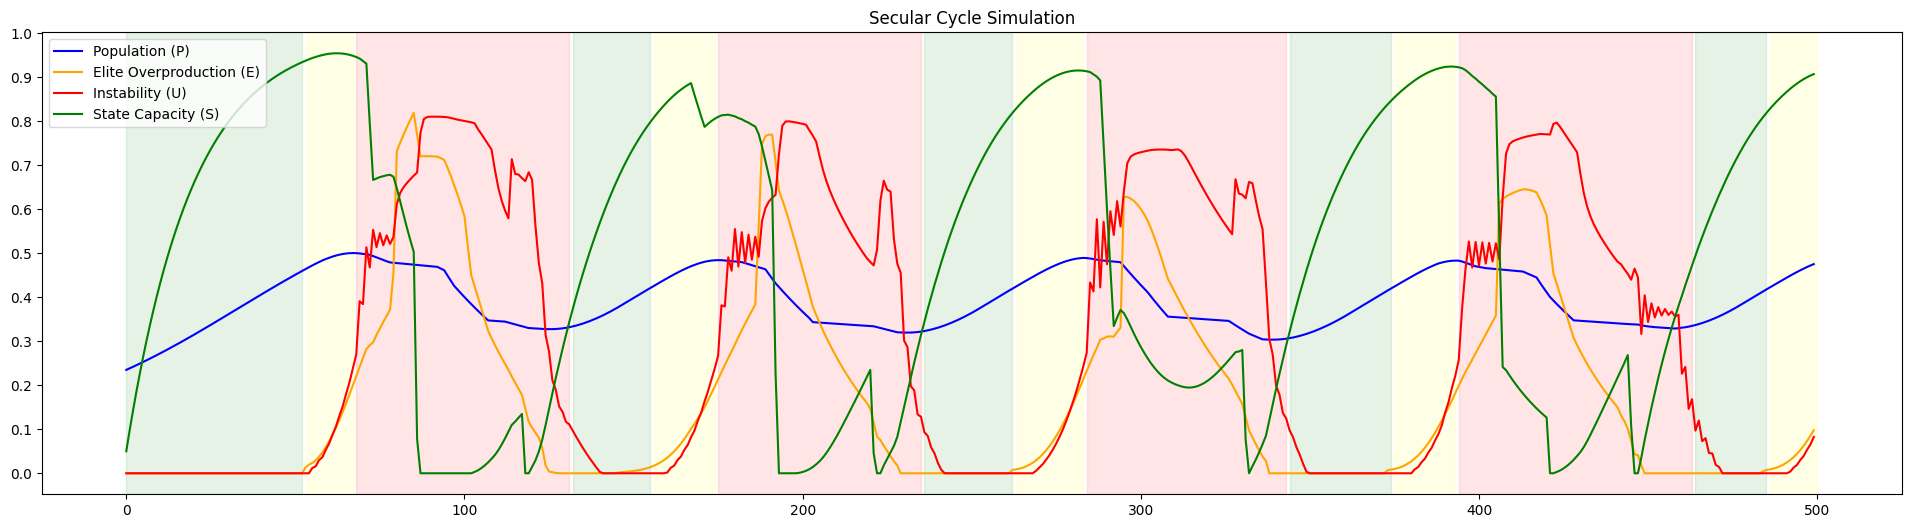

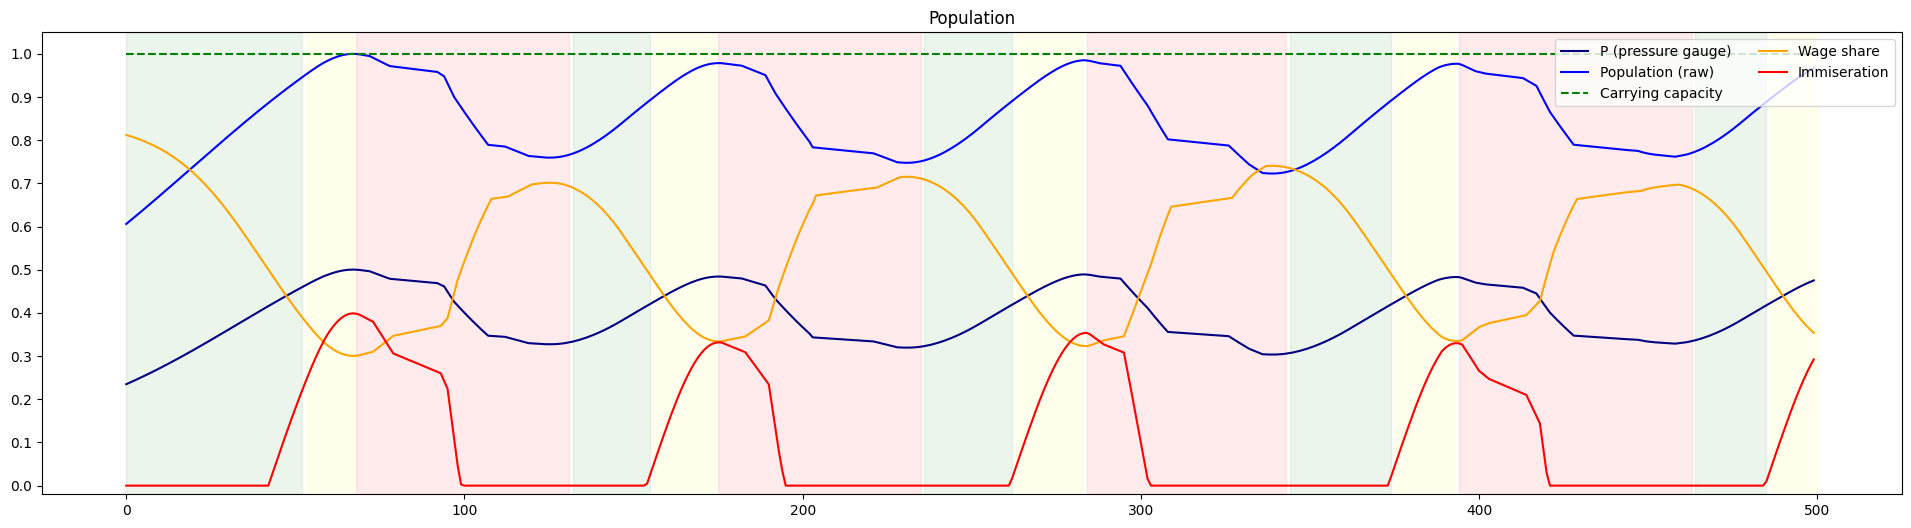

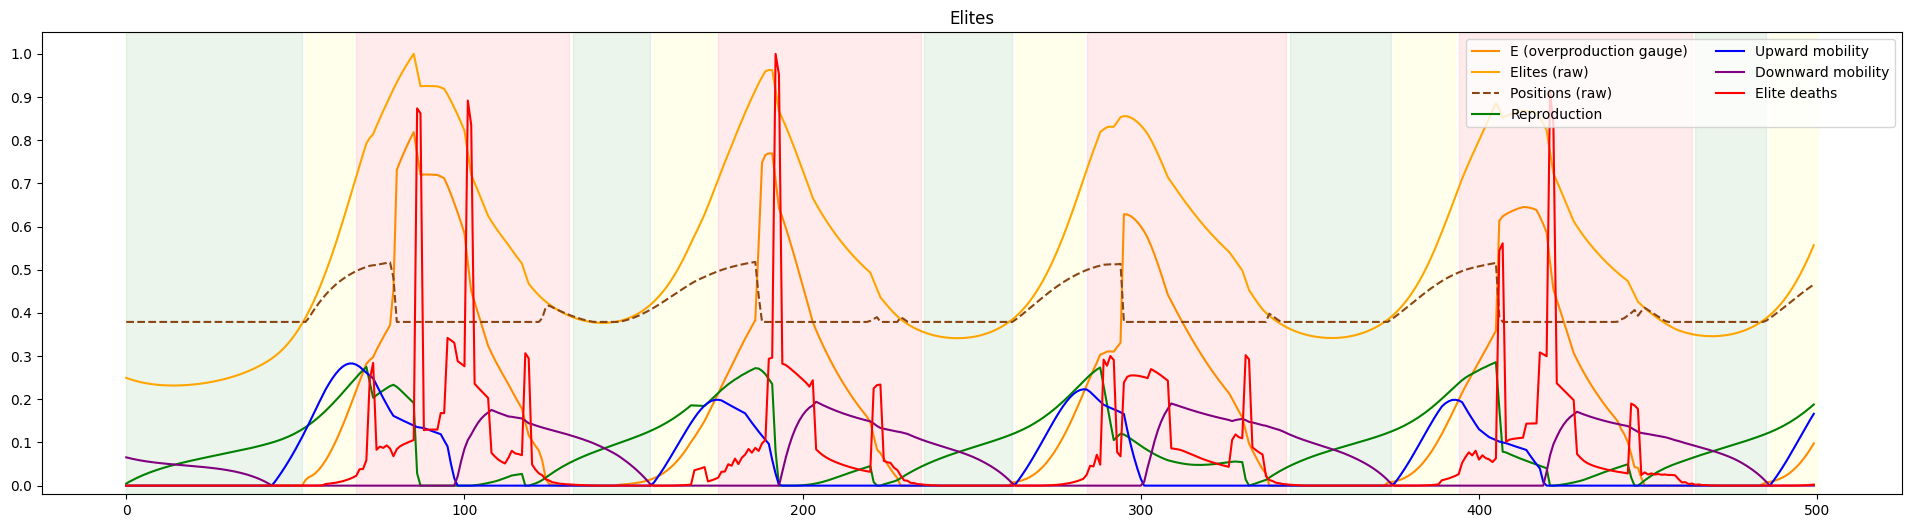

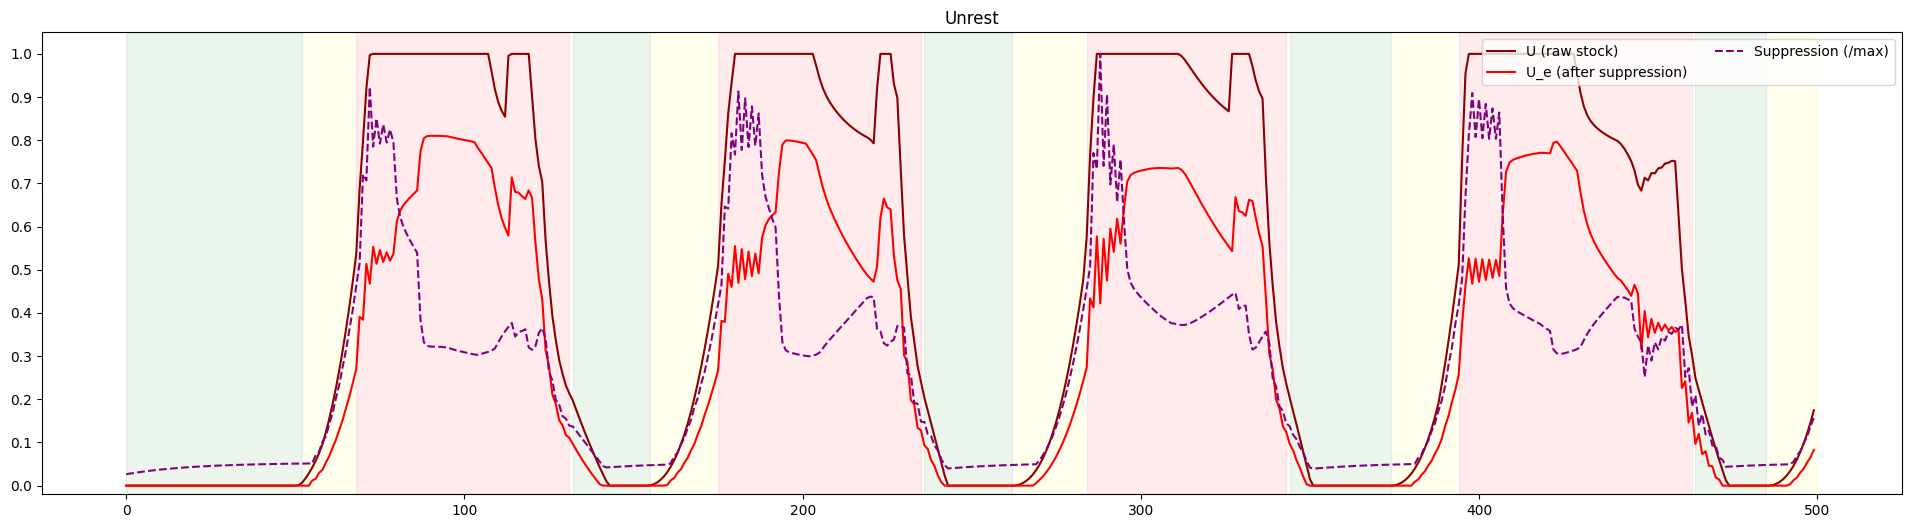

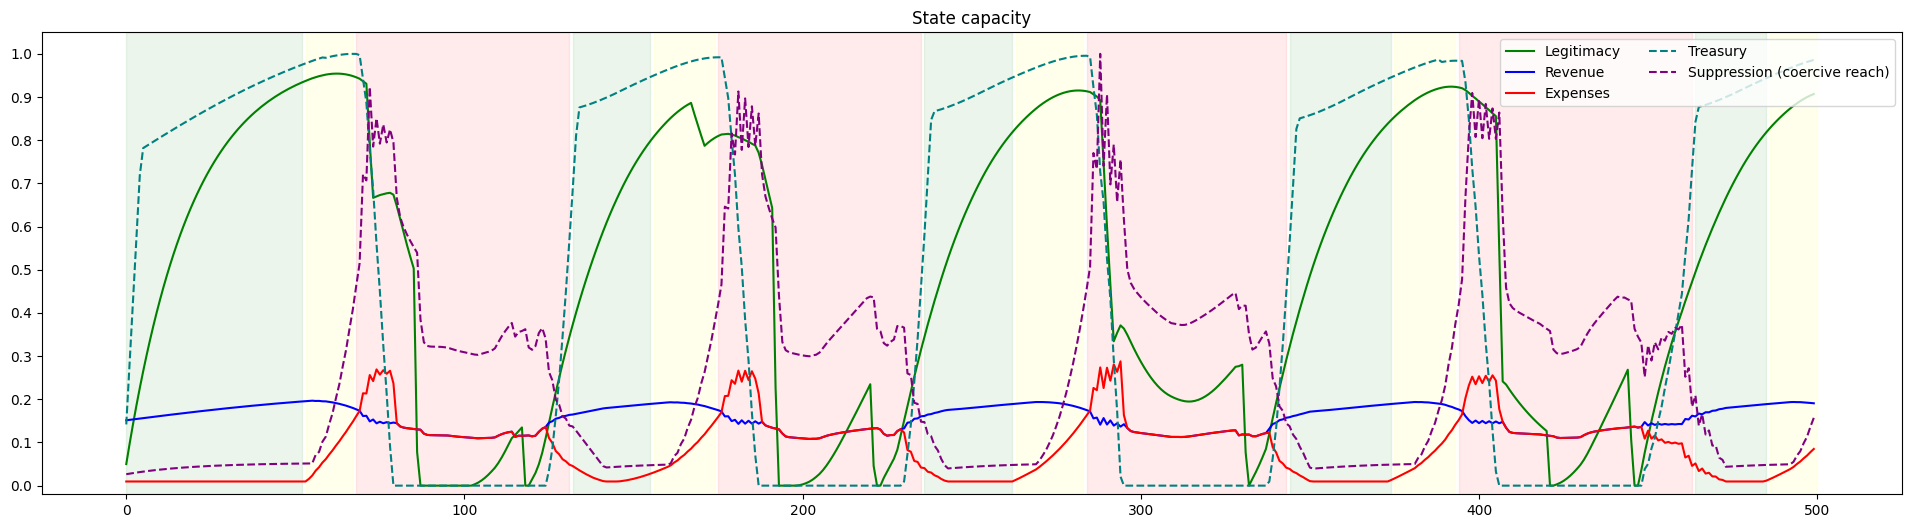

In [46]:
from new_model import FinalSim
from plot_tools import plot_population, plot_elites, plot_state, plot_unrest

random.seed(42)

final_sim = FinalSim()
for t in range(500):
    final_sim.step(t)

plot_simulation(    
    final_sim.P_history, final_sim.E_history, final_sim.U_e_history, final_sim.S_history, final_sim.phase_history
)
plot_population(
    P = final_sim.P_history,
    population=final_sim.population_history,
    carrying_capacity=final_sim.carrying_capacity_history,
    wage_share=final_sim.wage_history,
    immiseration=final_sim.immiseration_history,
    phase=final_sim.phase_history,
)
plot_elites(
    E = final_sim.E_history,
    elites= final_sim.elites_history,
    positions=final_sim.positions_history,
    reproduction=final_sim.e_reproduction_history,
    up_mobility=final_sim.e_mobility_up_history,
    down_mobility=final_sim.e_mobility_down_history,
    deaths=final_sim.e_deaths_history,
    phase=final_sim.phase_history
)
plot_unrest(final_sim.U_history, final_sim.U_e_history, suppression=final_sim.suppression_history, phase=final_sim.phase_history)
plot_state(
    legitimacy=final_sim.legitimacy_history,
    revenue=final_sim.revenue_history,
    expenses=final_sim.expenses_history,
    suppression=final_sim.suppression_history,
    treasury=final_sim.treasury_history,
    phase=final_sim.phase_history
)
# plot_simulation(    
#     simple_sim.P_history, simple_sim.E_history, simple_sim.U_e_history, simple_sim.S_history, simple_sim.phase_history
# )

In [14]:
population = 75
carrying_cap = 100

random.seed(42)

birth_rate = final_sim.get_birth_rate(population, carrying_cap)
death_rate = final_sim.get_death_rate(population, carrying_cap, birth_rate, famine_severity=0.0, disease_severity=0.0)
print("Birth Rate: ", round(birth_rate, 4))
print("Death Rate: ", round(death_rate, 4))

famine_severity = 0.0
disease_severity = 0.0

pop_vals = [population]
famines_vals = [famine_severity]
disease_vals = [disease_severity]
for t in range(500):
    birth_rate = final_sim.get_birth_rate(population, carrying_cap, start_decline=0.75, end_decline=1.25)
    death_rate = final_sim.get_death_rate(population, carrying_cap, birth_rate, famine_severity, disease_severity)
    population = population + (birth_rate - death_rate) * population

    if random.random() < (population/carrying_cap) ** 2 * 0.02:  # Probability of disease outbreak increases with population pressure
        disease_severity += random.uniform(0.0, 1.0) ** 2
    else:
        disease_severity = max(0.0, disease_severity * 0.9 - 0.02)  # Disease severity decays over time

    if random.random() < 0.1:  # 10% chance of drought each step
        food_capacity = carrying_cap * random.uniform(0.5, 1.0)  # Drought reduces carrying capacity
        famine_severity += min(1.0, max(0.0, (population - food_capacity) / food_capacity))
    else:
        famine_severity = max(0.0, famine_severity * 0.4 - 0.05)  # Famine severity decays over time

    pop_vals.append(population)
    famines_vals.append(famine_severity * carrying_cap)  # Scale famine severity for plotting
    disease_vals.append(disease_severity * carrying_cap)


plt.figure(figsize=(12, 6))
plt.plot(pop_vals, label="Population", color="tab:blue")
plt.plot(famines_vals, label="Famine Severity", color="tab:orange")
plt.plot(disease_vals, label="Disease Severity", color="tab:red")
plt.title("Population Dynamics with Famine and Disease")
plt.xlabel("Time Steps")

TypeError: FinalSim.get_birth_rate() missing 1 required positional argument: 'security'

In [ ]:
from sim_lab import simulate, summary, hum_check, trace_first_crisis

sim, h = simulate(6000)

print("=== SUMMARY ===");            summary(h)
print("\n=== FRACTURE UNREST SHAPE (hum test) ==="); hum_check(h)
print("\n=== FIRST CRISIS, TICK BY TICK ==="); trace_first_crisis(h, post=200)

=== SUMMARY ===
  split P/S/F %:    {'pros': 30, 'strain': 36, 'frac': 34}   stuck=False
  periods:          [120, 119, 119, 119, 119, 119, 119, 119, 119, 119]  mean=119.0
  crises:           50  lengths=[40, 40, 40, 40, 40, 40, 40, 40, 40, 40]
  elite cull depth: [0.48, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5]  (0=wiped,1=none)
  pop crash depth:  [0.27, 0.26, 0.26, 0.26, 0.26, 0.26, 0.26, 0.26, 0.26, 0.26]
  E           range: (0.0, 0.666)
  U_e         range: (0.0, 0.701)
  legitimacy  range: (0.0, 1.0)
  security    range: (0.1, 0.85)
  elites      range: (0.006, 0.07)
  population  range: (0.605, 0.961)
  treasury    range: (0.088, 0.613)
  psi         range: (0.0, 5.718)
  alpha       range: (-5.6, 1.241)
  unrest: 2575 active ticks | 100% partial(<0.9) | mean-active 0.32

=== FRACTURE UNREST SHAPE (hum test) ===
  (no fractures)

=== FIRST CRISIS, TICK BY TICK ===
t        phase    elites       U_e       psi  overprod  legitima  security  populati  treasury         w        